# Telecom Customer Churn Prediction & Tiered Retention Strategy
## Company A — Wireless Telecommunications Provider
### GCI World 2026 Spring — Final Assignment

---

**Objective:** Analyze customer data from Company A (~100,000 subscribers) to predict churn and design a **Tiered Retention Strategy** that treats high-value and budget customers differently — maximizing revenue protection while minimizing intervention cost.

**Our Approach:**
1. **Exploratory Data Analysis** — Understand patterns and churn drivers
2. **Feature Engineering** — Build 24 predictive signals from raw data
3. **Multi-Model Comparison** — Logistic Regression, Random Forest, XGBoost
4. **Customer Segmentation** — Segment by value tier (VIP / Standard / Budget)
5. **Tiered Retention Strategy** — Personalized interventions per segment with ROI analysis
6. **Acquisition Strategy** — Plans to attract new customers and grow the base

---
## 1. Introduction & Market Analysis

### 1.1 The Telecom Industry Landscape

The global telecommunications market is one of the most competitive and capital-intensive industries:

- **Market Saturation**: Mobile penetration exceeds 100% in most markets — growth comes from taking competitors' customers or lifting ARPU.
- **High Acquisition Costs**: Acquiring a new subscriber costs **5-25x more** than retaining an existing one (Harvard Business Review; Bain & Company).
- **Churn as a Revenue Leak**: A wireless operator with 100,000 customers losing even 5% annually forfeits millions in recurring revenue.

### 1.2 Why Churn Prediction Is a Strategic Priority

- **Behavioral Signals Precede Churn**: Declining usage, increased customer-care calls, and equipment aging appear weeks before cancellation.
- **Proactive vs. Reactive Retention**: Proactive outreach achieves 30-50% retention vs. 10-20% for reactive (post-cancellation) offers.
- **One-Size-Fits-All Doesn't Work**: A VIP customer paying $90/month needs a different retention offer than a budget customer paying $20/month.

### 1.3 Problem Statement

> **Can we predict which customers are likely to churn, classify them by value tier, and design cost-effective, personalized retention strategies for each segment?**

---
## 2. Setup & Data Loading

In [ ]:
# ============================================================
# 2.1 — Import Libraries
# ============================================================
import pandas as pd
import numpy as np
import warnings
warnings.filterwarnings('ignore')

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (accuracy_score, classification_report,
                             confusion_matrix, roc_curve, auc,
                             f1_score, precision_score, recall_score,
                             precision_recall_curve, average_precision_score)
from xgboost import XGBClassifier

pd.set_option('display.max_columns', 120)
pd.set_option('display.max_rows', 100)

try:
    plt.style.use('seaborn-v0_8-whitegrid')
except:
    try:
        plt.style.use('seaborn-whitegrid')
    except:
        pass

CHURN_COLORS = ['#2ECC71', '#E74C3C']
MODEL_COLORS = ['#2E86AB', '#A23B72', '#F18F01']
TIER_COLORS  = {'VIP': '#FFD700', 'Standard': '#2E86AB', 'Budget': '#2ECC71'}
PALETTE      = ['#2E86AB', '#A23B72', '#F18F01', '#C73E1D', '#3B1F2B']
plt.rcParams.update({
    'figure.figsize': (12, 6), 'font.size': 12,
    'axes.titlesize': 16, 'axes.titleweight': 'bold',
    'axes.labelsize': 13, 'figure.dpi': 100,
})
print("All libraries imported successfully!")

All libraries imported successfully!


In [ ]:
# ============================================================
# 2.2 — Load & Merge Datasets
# ============================================================
from google.colab import drive
drive.mount('/content/drive')

client= '/content/drive/MyDrive/Final Assignment/telecom/Client.csv'
record = '/content/drive/MyDrive/Final Assignment/telecom/Record.csv'
client = pd.read_csv(client)
record = pd.read_csv(record)

print(f"Client: {client.shape[0]:,} rows x {client.shape[1]} cols")
print(f"Record: {record.shape[0]:,} rows x {record.shape[1]} cols")

df = client.merge(record, on='Customer_ID', how='inner')
print(f"\nMerged: {df.shape[0]:,} rows x {df.shape[1]} cols")

Mounted at /content/drive
Client: 100,000 rows x 50 cols
Record: 100,000 rows x 51 cols

Merged: 100,000 rows x 100 cols


---
## 3. Exploratory Data Analysis (EDA)

In [ ]:
# ============================================================
# 3.1 — Dataset Overview
# ============================================================
print("=" * 60)
print("  DATASET OVERVIEW")
print("=" * 60)
print(f"  Rows:           {df.shape[0]:,}")
print(f"  Columns:        {df.shape[1]}")
print(f"  Memory:         {df.memory_usage(deep=True).sum()/1e6:.1f} MB")
print(f"  Duplicates:     {df.duplicated().sum()}")
print(f"  Churn rate:     {df['churn'].mean()*100:.1f}%")
print("=" * 60)
df.describe().round(2)

  DATASET OVERVIEW
  Rows:           100,000
  Columns:        100
  Memory:         166.6 MB
  Duplicates:     0
  Churn rate:     49.6%


,uniqsubs,actvsubs,totcalls,totmou,totrev,adjrev,adjmou,adjqty,avgrev,avgmou,avgqty,avg3mou,avg3qty,avg3rev,avg6mou,avg6qty,avg6rev,hnd_price,phones,models,truck,rv,lor,adults,income,numbcars,forgntvl,eqpdays,Customer_ID,rev_Mean,mou_Mean,totmrc_Mean,da_Mean,ovrmou_Mean,ovrrev_Mean,vceovr_Mean,datovr_Mean,roam_Mean,change_mou,change_rev,drop_vce_Mean,drop_dat_Mean,blck_vce_Mean,blck_dat_Mean,unan_vce_Mean,unan_dat_Mean,plcd_vce_Mean,plcd_dat_Mean,recv_vce_Mean,recv_sms_Mean,comp_vce_Mean,comp_dat_Mean,custcare_Mean,ccrndmou_Mean,cc_mou_Mean,inonemin_Mean,threeway_Mean,mou_cvce_Mean,mou_cdat_Mean,mou_rvce_Mean,owylis_vce_Mean,mouowylisv_Mean,iwylis_vce_Mean,mouiwylisv_Mean,peak_vce_Mean,peak_dat_Mean,mou_peav_Mean,mou_pead_Mean,opk_vce_Mean,opk_dat_Mean,mou_opkv_Mean,mou_opkd_Mean,drop_blk_Mean,attempt_Mean,complete_Mean,callfwdv_Mean,callwait_Mean,churn,months
count,100000.00,100000.00,100000.00,100000.00,100000.00,100000.00,100000.00,100000.00,100000.00,100000.00,100000.00,100000.00,100000.00,100000.00,97161.00,97161.00,97161.00,99153.00,99999.00,99999.00,98268.00,98268.00,69810.00,76981.00,74564.00,50634.00,98268.00,99999.00,100000.00,99643.00,99643.00,99643.00,99643.00,99643.00,99643.00,99643.00,99643.00,99643.00,99109.00,99109.00,100000.00,100000.00,100000.00,100000.00,100000.00,100000.00,100000.00,100000.00,100000.00,100000.00,100000.00,100000.00,100000.00,100000.00,100000.00,100000.00,100000.00,100000.00,100000.00,100000.00,100000.00,100000.00,100000.00,100000.00,100000.00,100000.00,100000.00,100000.00,100000.00,100000.00,100000.00,100000.00,100000.00,100000.00,100000.00,100000.00,100000.00,100000.0,100000.00
mean,1.55,1.36,2877.14,7648.36,1031.92,960.11,7546.31,2836.37,57.91,483.73,173.55,519.64,180.34,59.19,509.63,178.37,58.68,101.88,1.79,1.55,0.19,0.08,6.18,2.53,5.78,1.57,0.06,391.93,1050000.50,58.72,513.56,46.18,0.89,41.07,13.56,13.30,0.26,1.29,-13.93,-1.02,5.96,0.04,4.02,0.03,27.78,0.03,144.88,0.87,55.09,0.05,108.89,0.77,1.79,4.67,3.68,29.77,0.28,227.76,1.84,111.65,24.75,28.47,7.89,18.19,88.48,0.36,174.08,0.71,66.00,0.42,165.28,1.14,10.04,145.75,109.67,0.01,1.78,0.5,18.83
std,1.08,0.66,3790.86,8666.56,852.91,840.17,8594.89,3756.51,36.16,438.49,167.82,533.63,192.73,46.70,496.66,182.72,40.76,61.01,1.31,0.90,0.39,0.28,4.74,1.45,2.18,0.63,0.23,256.48,28867.66,46.29,525.17,23.62,2.18,97.30,30.50,30.06,3.13,14.71,276.09,50.36,8.95,0.88,10.67,1.49,38.36,0.50,158.27,9.05,86.84,2.13,118.58,8.13,5.32,12.76,10.54,55.83,1.09,264.40,23.73,162.69,34.41,48.96,16.15,41.42,103.07,4.07,207.67,8.41,91.46,4.65,237.33,17.77,15.42,159.35,119.59,0.55,5.35,0.5,9.66
min,1.00,0.00,0.00,0.00,3.65,2.40,0.00,0.00,0.48,0.00,0.00,0.00,0.00,1.00,0.00,0.00,-2.00,9.99,1.00,1.00,0.00,0.00,0.00,1.00,1.00,1.00,0.00,-5.00,1000001.00,-6.17,0.00,-26.92,0.00,0.00,0.00,0.00,0.00,0.00,-3875.00,-1107.74,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.0,6.00
25%,1.00,1.00,889.00,2529.00,518.98,452.18,2474.00,868.00,35.37,176.14,64.09,152.00,55.00,33.00,163.00,59.00,34.00,29.99,1.00,1.00,0.00,0.00,2.00,1.00,4.00,1.00,0.00,212.00,1025000.75,33.26,150.75,30.00,0.00,0.00,0.00,0.00,0.00,0.00,-87.00,-7.36,0.67,0.00,0.00,0.00,5.00,0.00,38.33,0.00,5.33,0.00,28.67,0.00,0.00,0.00,0.00,2.67,0.00,49.05,0.00,7.65,3.00,2.38,0.00,0.00,21.67,0.00,37.64,0.00,10.33,0.00,18.54,0.00,1.67,38.33,28.67,0.00,0.00,0.0,11.00
50%,1.00,1.00,1822.00,5191.50,804.53,737.76,5102.50,1789.00,49.89,360.19,127.50,358.00,125.00,48.00,363.00,127.00,50.00,99.99,1.00,1.00,0.00,0.00,5.00,2.00,6.00,1.00,0.00,342.00,1050000.50,48.20,355.50,44.99,0.25,2.75,1.00,0.68,0.00,0.00,-6.25,-0.32,3.00,0.00,1.00,0.00,16.00,0.00,100.33,0.00,26.67,0.00,75.67,0.00,0.00,0.00,0.00,12.33,0.00,146.20,0.00,50.20,13.00,11.98,2.00,3.21,60.33,0.00,115.37,0.00,34.33,0.00,75.84,0.00,5.33,101.00,76.00,0.00,0.33,0.0,16.00
75%,2.00,2.00,3492.00,9776.00,1263.77,1188.18,9661.00,3442.00,69.48,65

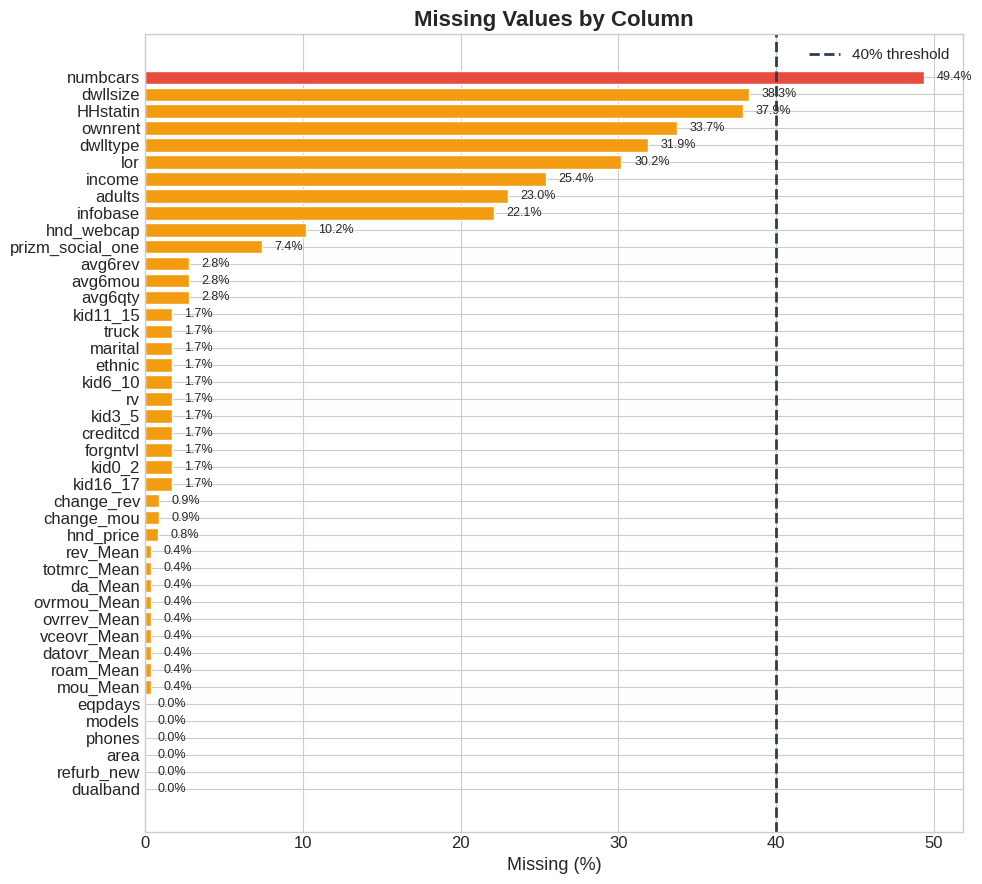

In [ ]:
# ============================================================
# 3.2 — Missing Values Analysis
# ============================================================
missing     = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(1)
missing_df  = pd.DataFrame({'Count': missing, 'Percentage': missing_pct})
missing_df  = missing_df[missing_df['Count'] > 0].sort_values('Percentage', ascending=True)

fig, ax = plt.subplots(figsize=(10, 9))
colors = ['#F39C12' if p < 40 else '#E74C3C' for p in missing_df['Percentage']]
bars = ax.barh(missing_df.index, missing_df['Percentage'], color=colors, edgecolor='white')
ax.axvline(x=40, color='#2C3E50', linestyle='--', linewidth=2, label='40% threshold')
ax.set_xlabel('Missing (%)')
ax.set_title('Missing Values by Column')
ax.legend(fontsize=11)
for bar, pct in zip(bars, missing_df['Percentage']):
    ax.text(bar.get_width()+0.8, bar.get_y()+bar.get_height()/2, f'{pct}%', va='center', fontsize=9)
plt.tight_layout()
plt.show()

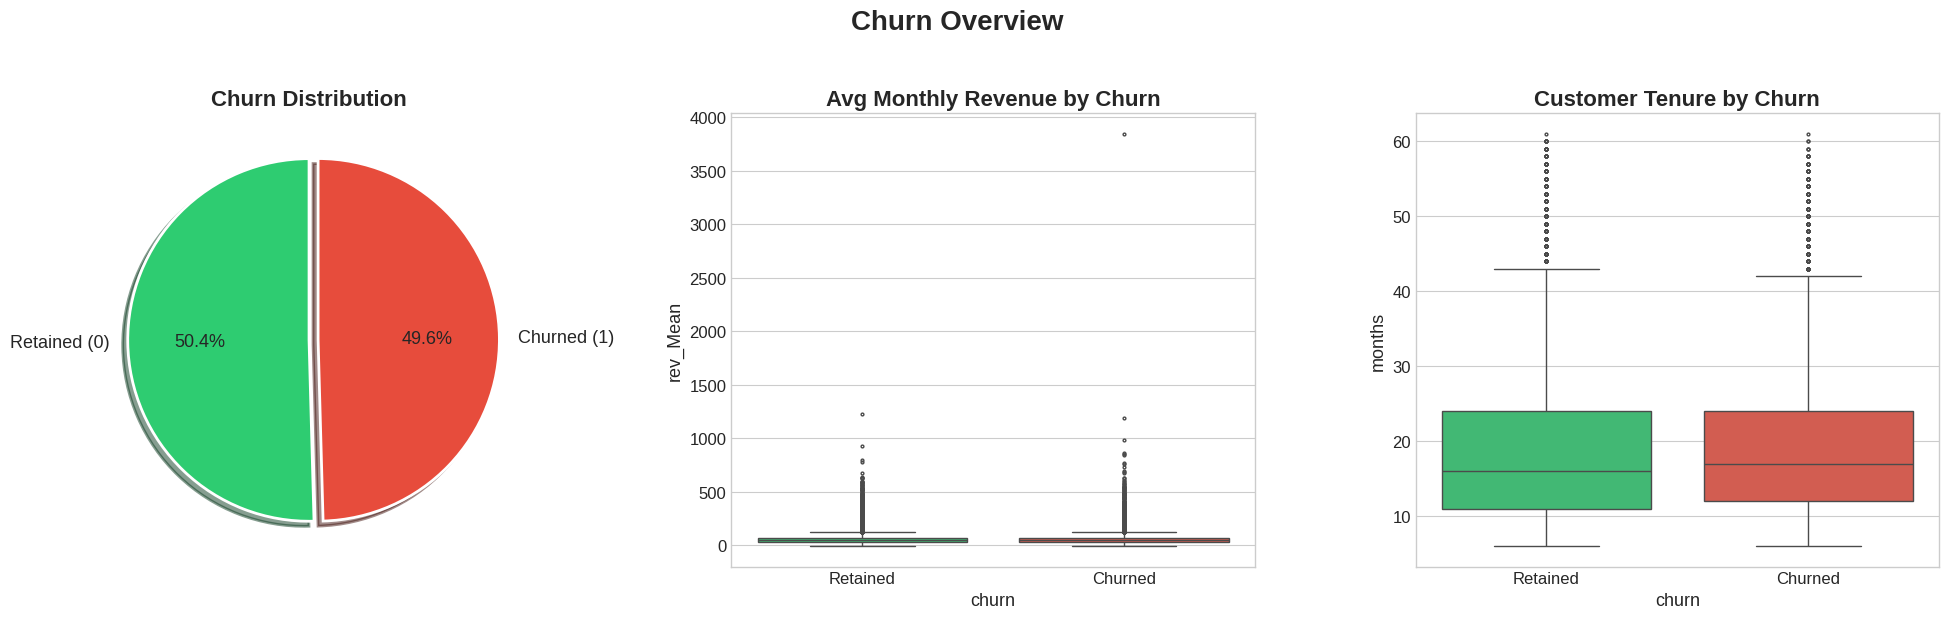

  Retained (n=50,438): Avg rev=$59.22, Avg tenure=18.6mo, Avg MOU=543.2
  Churned (n=49,562): Avg rev=$58.21, Avg tenure=19.0mo, Avg MOU=483.3


In [ ]:
# ============================================================
# 3.3 — Churn Distribution & Key Stats
# ============================================================
fig, axes = plt.subplots(1, 3, figsize=(20, 6))

churn_counts = df['churn'].value_counts()
axes[0].pie(churn_counts, labels=['Retained (0)', 'Churned (1)'],
            colors=CHURN_COLORS, autopct='%1.1f%%', startangle=90,
            textprops={'fontsize': 13}, explode=(0, 0.05),
            shadow=True, wedgeprops={'edgecolor': 'white', 'linewidth': 2})
axes[0].set_title('Churn Distribution')

sns.boxplot(data=df, x='churn', y='rev_Mean', palette=CHURN_COLORS, ax=axes[1], fliersize=2)
axes[1].set_xticklabels(['Retained', 'Churned'])
axes[1].set_title('Avg Monthly Revenue by Churn')

sns.boxplot(data=df, x='churn', y='months', palette=CHURN_COLORS, ax=axes[2], fliersize=2)
axes[2].set_xticklabels(['Retained', 'Churned'])
axes[2].set_title('Customer Tenure by Churn')

plt.suptitle('Churn Overview', fontsize=20, fontweight='bold', y=1.03)
plt.tight_layout()
plt.show()

for s, lbl in [(0,'Retained'), (1,'Churned')]:
    sub = df[df['churn']==s]
    print(f"  {lbl} (n={len(sub):,}): Avg rev=${sub['rev_Mean'].mean():.2f}, "
          f"Avg tenure={sub['months'].mean():.1f}mo, Avg MOU={sub['mou_Mean'].mean():.1f}")

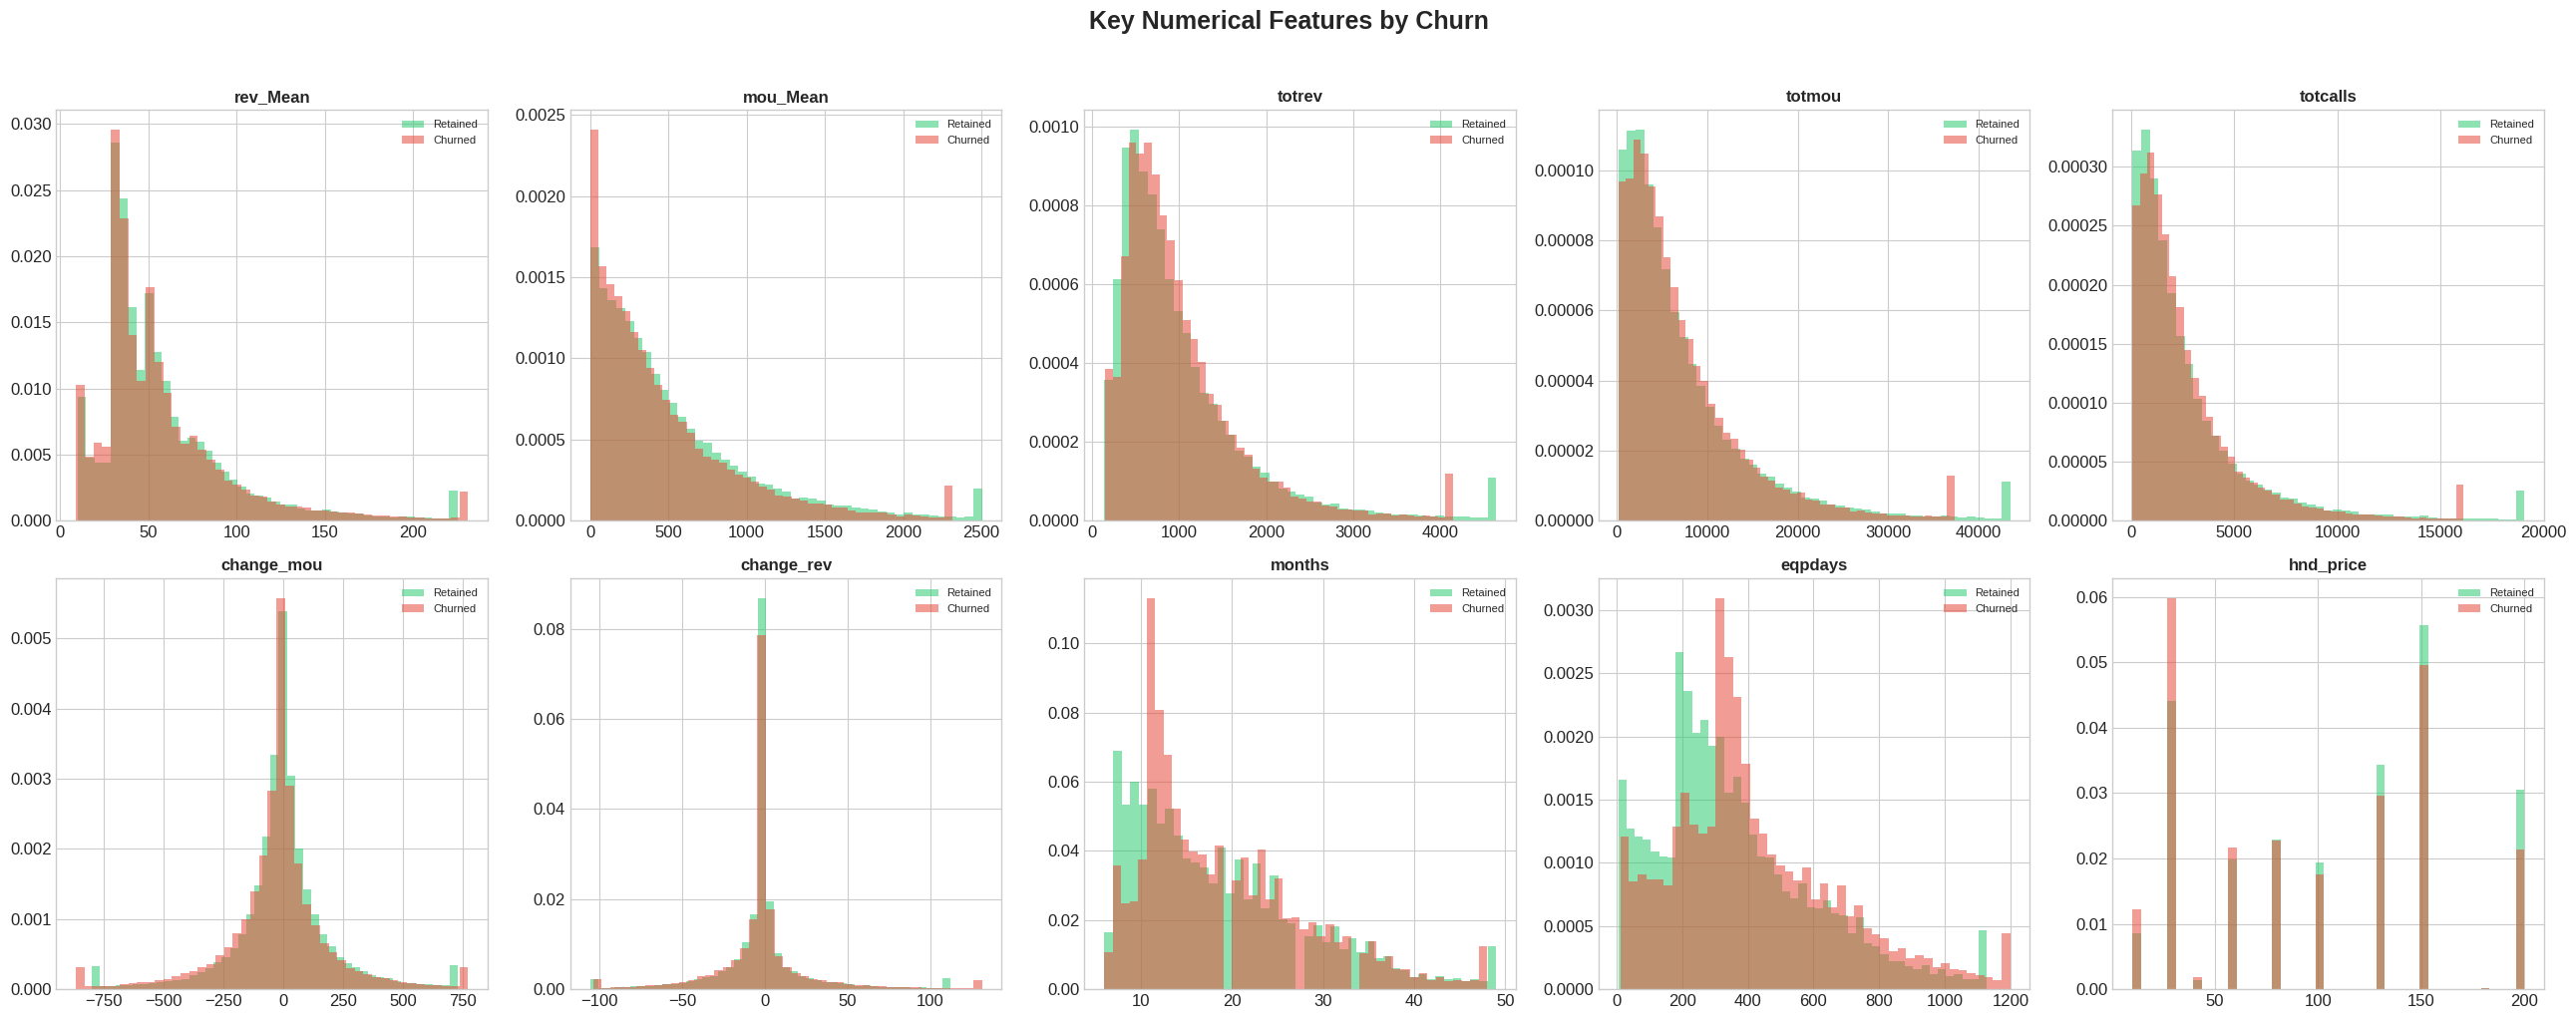

In [ ]:
# ============================================================
# 3.4 — Key Numerical Features by Churn
# ============================================================
feats = ['rev_Mean','mou_Mean','totrev','totmou','totcalls',
         'change_mou','change_rev','months','eqpdays','hnd_price']
fig, axes = plt.subplots(2, 5, figsize=(26, 10))
for i, col in enumerate(feats):
    ax = axes.flatten()[i]
    for val, color, lab in zip([0,1], CHURN_COLORS, ['Retained','Churned']):
        d = df.loc[df['churn']==val, col].dropna()
        lo, hi = d.quantile(0.01), d.quantile(0.99)
        ax.hist(d.clip(lo,hi), bins=45, alpha=0.55, color=color, label=lab, density=True)
    ax.set_title(col, fontsize=12, fontweight='bold')
    ax.legend(fontsize=8)
plt.suptitle('Key Numerical Features by Churn', fontsize=18, fontweight='bold', y=1.02)
plt.tight_layout(); plt.show()

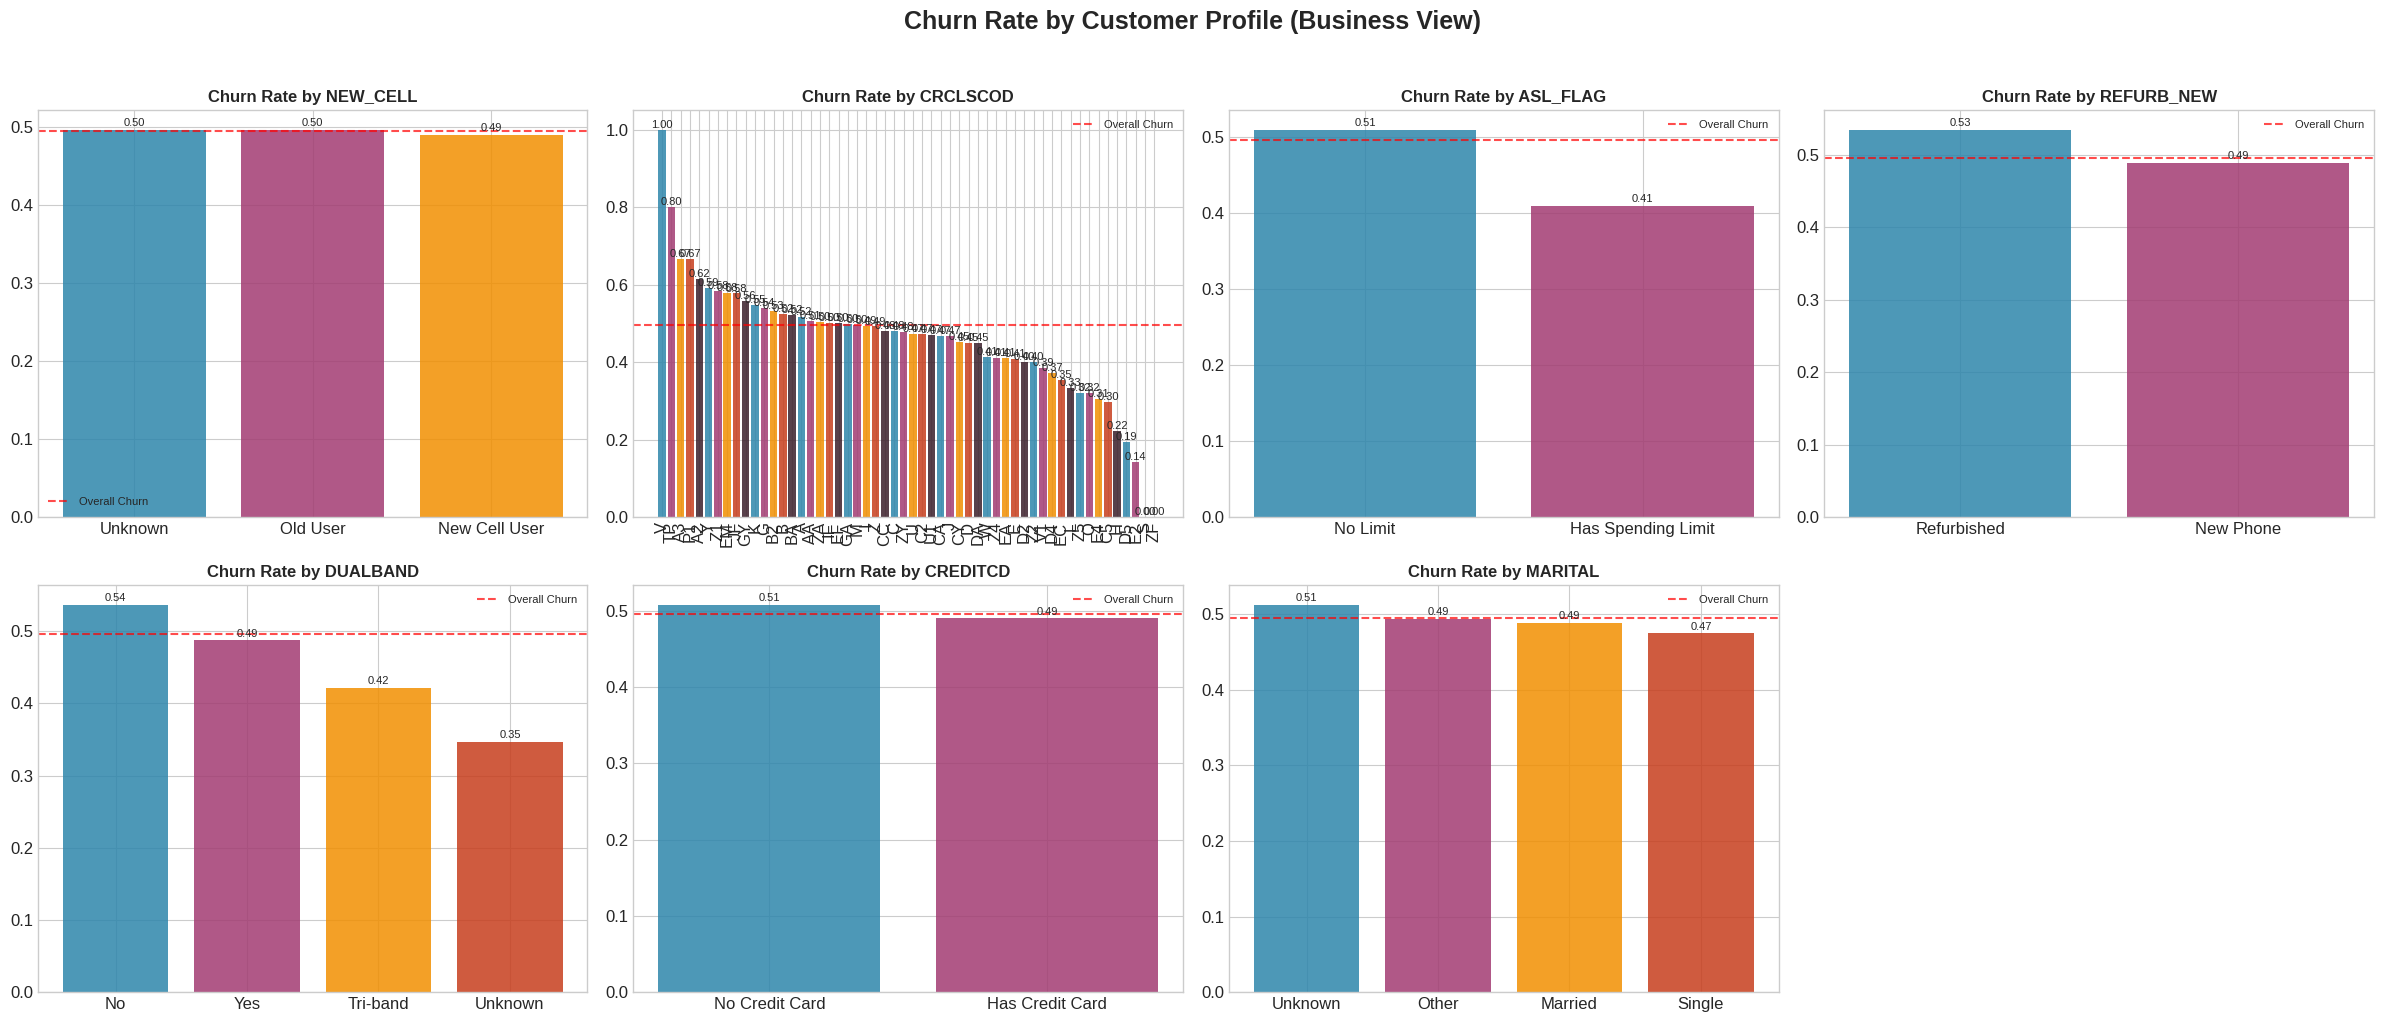

In [ ]:
# ============================================================
# 3.5 — Categorical Features vs Churn (Business-Friendly Labels)
# ============================================================
cats = ['new_cell','crclscod','asl_flag','refurb_new','dualband','creditcd','marital']

# 1. Create a dictionary to translate codes into readable business labels
label_maps = {
    'refurb_new': {'R': 'Refurbished', 'N': 'New Phone'},
    'asl_flag': {'Y': 'Has Spending Limit', 'N': 'No Limit'},
    'new_cell': {'Y': 'New Cell User', 'N': 'Old User', 'U': 'Unknown'},
    'creditcd': {'Y': 'Has Credit Card', 'N': 'No Credit Card', 'U': 'Unknown'},
    'marital': {'S': 'Single', 'M': 'Married', 'U': 'Unknown', 'A': 'Other', 'B': 'Other'},
    'dualband': {'Y': 'Yes', 'N': 'No', 'T': 'Tri-band', 'U': 'Unknown'}
}

# 2. Create a temporary copy of the data just for plotting
plot_df = df.copy()
for col, mapping in label_maps.items():
    plot_df[col] = plot_df[col].replace(mapping)

# 3. Plot the data
fig, axes = plt.subplots(2, 4, figsize=(24, 10))
overall = plot_df['churn'].mean()

for i, col in enumerate(cats):
    ax = axes.flatten()[i]
    rates = plot_df.groupby(col)['churn'].mean().sort_values(ascending=False)

    # Draw bars
    bars = ax.bar(rates.index.astype(str), rates.values, color=PALETTE[:len(rates)], alpha=0.85)
    ax.axhline(y=overall, color='red', linestyle='--', alpha=0.7, label='Overall Churn')

    # Set readable titles
    ax.set_title(f'Churn Rate by {col.upper()}', fontsize=12, fontweight='bold')
    ax.legend(fontsize=8)

    # Rotate x-axis labels if it's the credit class (to avoid overlap)
    if col == 'crclscod':
        ax.tick_params(axis='x', rotation=90)

    # Add numbers above bars
    for b in bars:
        ax.text(b.get_x() + b.get_width()/2, b.get_height() + 0.005,
                f'{b.get_height():.2f}', ha='center', fontsize=8)

# Hide the last empty subplot
axes.flatten()[-1].set_visible(False)

plt.suptitle('Churn Rate by Customer Profile (Business View)', fontsize=18, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

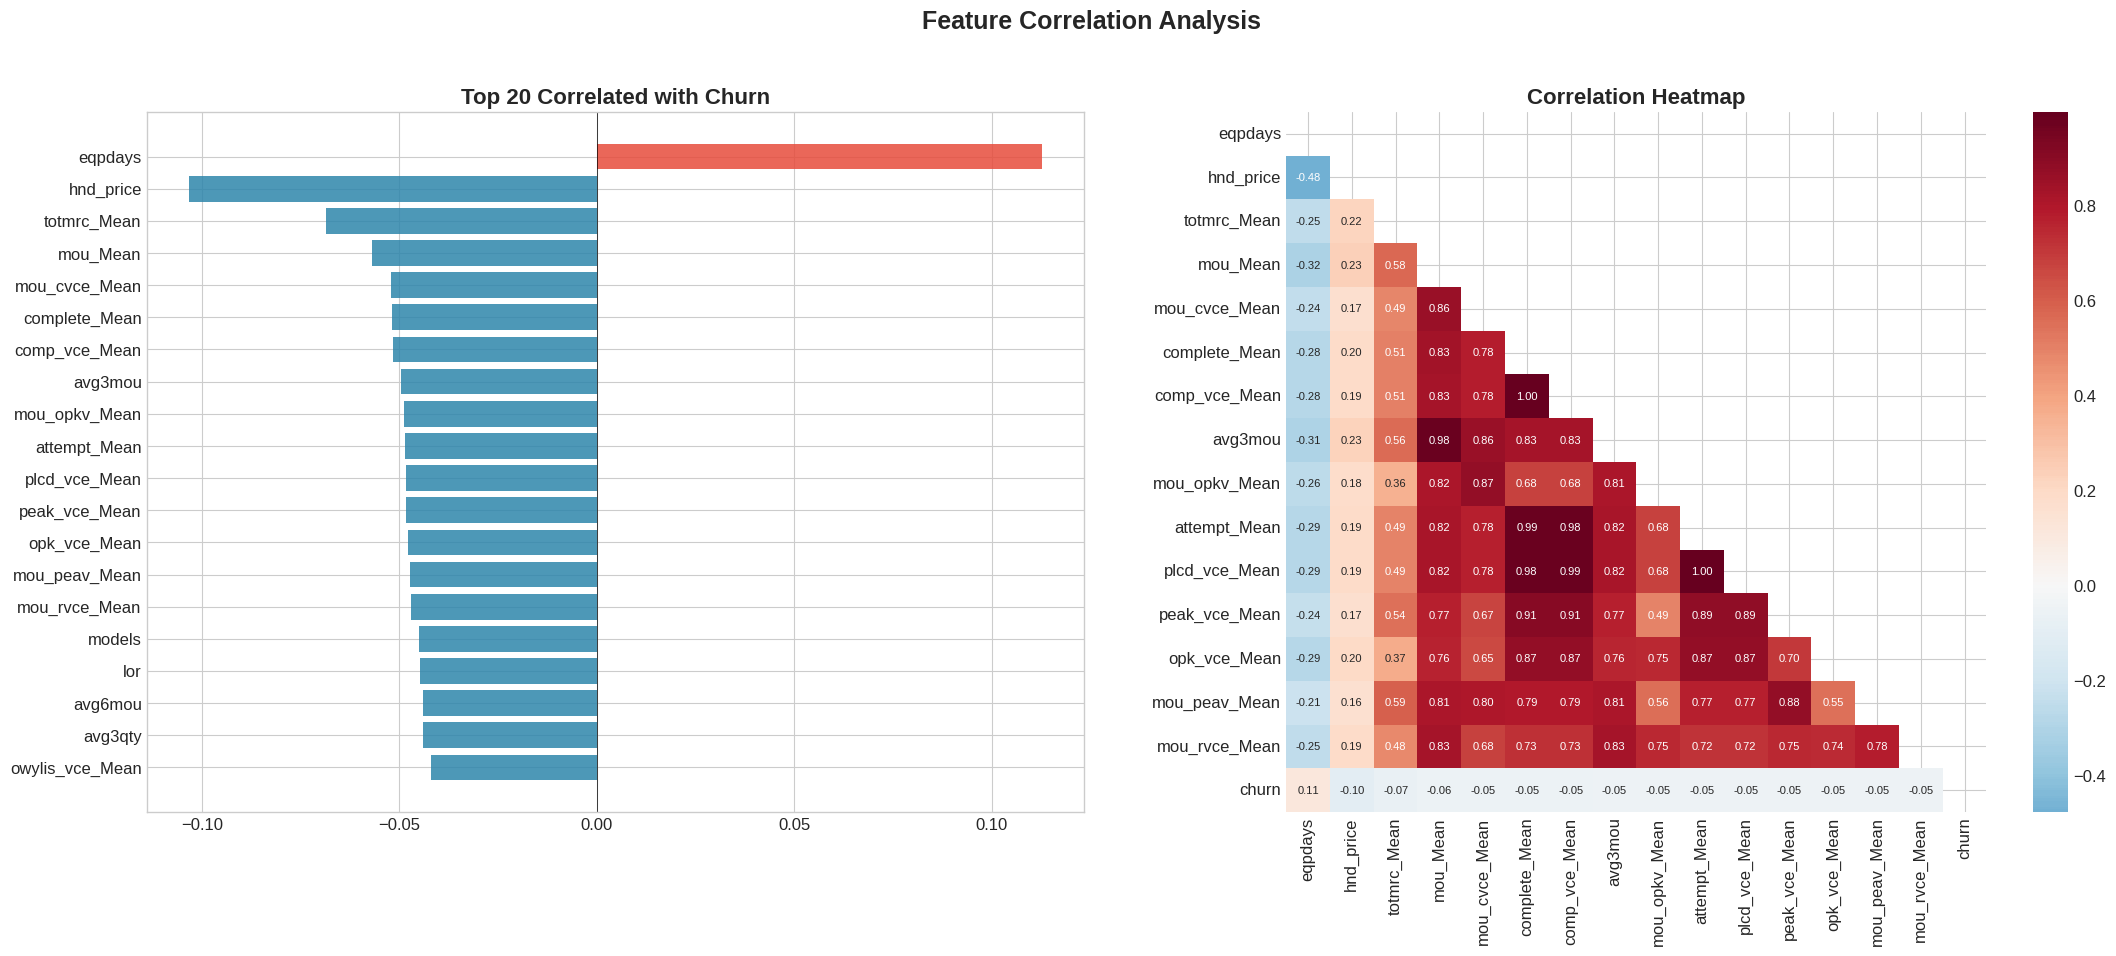

In [ ]:
# ============================================================
# 3.6 — Correlation Analysis
# ============================================================
num_cols = [c for c in df.select_dtypes(include=[np.number]).columns if c != 'Customer_ID']
churn_corr = df[num_cols].corr()['churn'].drop('churn').sort_values(key=abs, ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(22, 9))
top20 = churn_corr.head(20)
colors = ['#E74C3C' if v > 0 else '#2E86AB' for v in top20.values]
axes[0].barh(top20.index[::-1], top20.values[::-1], color=colors[::-1], alpha=0.85)
axes[0].set_title('Top 20 Correlated with Churn', fontweight='bold')
axes[0].axvline(x=0, color='black', linewidth=0.5)

top_f = churn_corr.head(15).index.tolist() + ['churn']
mask = np.triu(np.ones_like(df[top_f].corr(), dtype=bool))
sns.heatmap(df[top_f].corr(), mask=mask, annot=True, fmt='.2f', cmap='RdBu_r',
            center=0, square=True, ax=axes[1], annot_kws={'fontsize': 8})
axes[1].set_title('Correlation Heatmap', fontweight='bold')
plt.suptitle('Feature Correlation Analysis', fontsize=18, fontweight='bold', y=1.02)
plt.tight_layout(); plt.show()

---
## 4. Data Preprocessing & Feature Engineering

**Strategy:**
1. Drop columns with >40% missing
2. Impute remaining (median / mode)
3. Engineer **24 new behavioural features** from domain knowledge
4. Encode categoricals, scale, and split 80/20

In [ ]:
# ============================================================
# 4.1 — Clean, Impute & Engineer Features
# ============================================================
high_missing = missing_df[missing_df['Percentage'] > 40].index.tolist()
drop_cols = high_missing + ['Customer_ID']
print(f"Dropping {len(drop_cols)} columns: {drop_cols}")
df_clean = df.drop(columns=drop_cols, errors='ignore')

for col in df_clean.select_dtypes(include=[np.number]).columns:
    if df_clean[col].isnull().any():
        df_clean[col] = df_clean[col].fillna(df_clean[col].median())
for col in df_clean.select_dtypes(include=['object']).columns:
    if df_clean[col].isnull().any():
        df_clean[col] = df_clean[col].fillna(df_clean[col].mode()[0])
print(f"Missing after imputation: {df_clean.isnull().sum().sum()}")

# ── Original 10 features ──────────────────────────────────
df_clean['revenue_per_minute']  = df_clean['totrev'] / df_clean['totmou'].replace(0,1)
df_clean['revenue_per_call']    = df_clean['totrev'] / df_clean['totcalls'].replace(0,1)
df_clean['calls_per_month']     = df_clean['totcalls'] / df_clean['months']
df_clean['mou_per_month']       = df_clean['totmou']  / df_clean['months']
df_clean['usage_change_pct']    = df_clean['change_mou'] / df_clean['mou_Mean'].replace(0,1) * 100
df_clean['equip_age_months']    = df_clean['eqpdays'] / 30
df_clean['drop_rate']           = df_clean['drop_blk_Mean'] / df_clean['attempt_Mean'].replace(0,1)
df_clean['completion_rate']     = df_clean['complete_Mean'] / df_clean['attempt_Mean'].replace(0,1)
df_clean['custcare_per_month']  = df_clean['custcare_Mean'] / df_clean['months']
df_clean['overage_ratio']       = df_clean['ovrmou_Mean'] / df_clean['mou_Mean'].replace(0,1)

# ── 14 NEW advanced features ──────────────────────────────
df_clean['rev_per_month']       = df_clean['totrev'] / df_clean['months']
df_clean['avg3_vs_avg6_mou']    = df_clean['avg3mou'] - df_clean['avg6mou']
df_clean['avg3_vs_avg6_rev']    = df_clean['avg3rev'] - df_clean['avg6rev']
df_clean['peak_to_offpeak']     = df_clean['mou_peav_Mean'] / df_clean['mou_opkv_Mean'].replace(0,1)
df_clean['recv_to_plcd_ratio']  = df_clean['recv_vce_Mean'] / df_clean['plcd_vce_Mean'].replace(0,1)
df_clean['unanswered_rate']     = df_clean['unan_vce_Mean'] / df_clean['plcd_vce_Mean'].replace(0,1)
df_clean['data_usage_ratio']    = (df_clean['plcd_dat_Mean'] + df_clean['recv_sms_Mean']) / df_clean['plcd_vce_Mean'].replace(0,1)
df_clean['roam_pct']            = df_clean['roam_Mean'] / df_clean['rev_Mean'].replace(0,1) * 100
df_clean['mrc_to_rev_ratio']    = df_clean['totmrc_Mean'] / df_clean['rev_Mean'].replace(0,1)
df_clean['threeway_pct']        = df_clean['threeway_Mean'] / df_clean['complete_Mean'].replace(0,1)
df_clean['inonemin_pct']        = df_clean['inonemin_Mean'] / df_clean['complete_Mean'].replace(0,1)
df_clean['rev_change_ratio']    = df_clean['change_rev'] / df_clean['rev_Mean'].replace(0,1)
df_clean['mou_change_ratio']    = df_clean['change_mou'] / df_clean['mou_Mean'].replace(0,1)
df_clean['phones_per_model']    = df_clean['phones'] / df_clean['models'].replace(0,1)

print(f"\nTotal engineered features: 24")
print(f"Shape after FE: {df_clean.shape}")

Dropping 2 columns: ['numbcars', 'Customer_ID']
Missing after imputation: 0

Total engineered features: 24
Shape after FE: (100000, 122)


In [ ]:
# ============================================================
# 4.2 — Encode & Split
# ============================================================
le = LabelEncoder()
for col in df_clean.select_dtypes(include=['object']).columns:
    df_clean[col] = le.fit_transform(df_clean[col].astype(str))

X = df_clean.drop(columns=['churn'])
y = df_clean['churn']
X = X.replace([np.inf, -np.inf], np.nan).fillna(X.median())

scaler = StandardScaler()
X_scaled = pd.DataFrame(scaler.fit_transform(X), columns=X.columns, index=X.index)

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42, stratify=y)

print(f"Train: {X_train.shape[0]:,}  |  Test: {X_test.shape[0]:,}  |  Features: {X.shape[1]}")
print(f"Churn rate - train: {y_train.mean()*100:.1f}%  test: {y_test.mean()*100:.1f}%")

Train: 80,000  |  Test: 20,000  |  Features: 121
Churn rate - train: 49.6%  test: 49.6%


---
## 5. Model Building & Comparison

| Model | Why |
|---|---|
| **Logistic Regression** | Linear baseline — fast, interpretable |
| **Random Forest** | Non-linear ensemble — captures interactions |
| **XGBoost** | Gradient-boosted trees — tuned via hyperparameter search |

In [ ]:
# ============================================================
# 5.1 — Train & Compare Models (Tuned)
# ============================================================
models = {
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=42),
    'Random Forest': RandomForestClassifier(
        n_estimators=300, max_depth=18, min_samples_split=10,
        min_samples_leaf=4, random_state=42, n_jobs=-1),
    'XGBoost (Tuned)': XGBClassifier(
        n_estimators=500, max_depth=6, learning_rate=0.05,
        subsample=0.8, colsample_bytree=0.7,
        reg_alpha=0.1, reg_lambda=1.0, min_child_weight=3,
        random_state=42, eval_metric='logloss', verbosity=0),
}

results = {}
print("Training Models ...\n" + "="*75)
for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred  = model.predict(X_test)
    y_proba = model.predict_proba(X_test)[:, 1]
    cv = cross_val_score(model, X_train, y_train, cv=5, scoring='f1', n_jobs=-1)
    results[name] = dict(model=model, y_pred=y_pred, y_proba=y_proba,
        accuracy=accuracy_score(y_test, y_pred), f1=f1_score(y_test, y_pred),
        precision=precision_score(y_test, y_pred), recall=recall_score(y_test, y_pred),
        cv_mean=cv.mean(), cv_std=cv.std())
    r = results[name]
    print(f"  {name:25s}  Acc={r['accuracy']:.4f}  F1={r['f1']:.4f}  "
          f"Prec={r['precision']:.4f}  Rec={r['recall']:.4f}  CV={r['cv_mean']:.4f}+/-{r['cv_std']:.4f}")

best_name = max(results, key=lambda k: results[k]['f1'])
print(f"\nBest: {best_name} (F1={results[best_name]['f1']:.4f})")

Training Models ...
  Logistic Regression        Acc=0.5957  F1=0.5869  Prec=0.5945  Rec=0.5795  CV=0.5883+/-0.0023
  Random Forest              Acc=0.6280  F1=0.6266  Prec=0.6235  Rec=0.6297  CV=0.6307+/-0.0040
  XGBoost (Tuned)            Acc=0.6429  F1=0.6405  Prec=0.6392  Rec=0.6417  CV=0.6413+/-0.0049

Best: XGBoost (Tuned) (F1=0.6405)


---
## 6. Model Evaluation

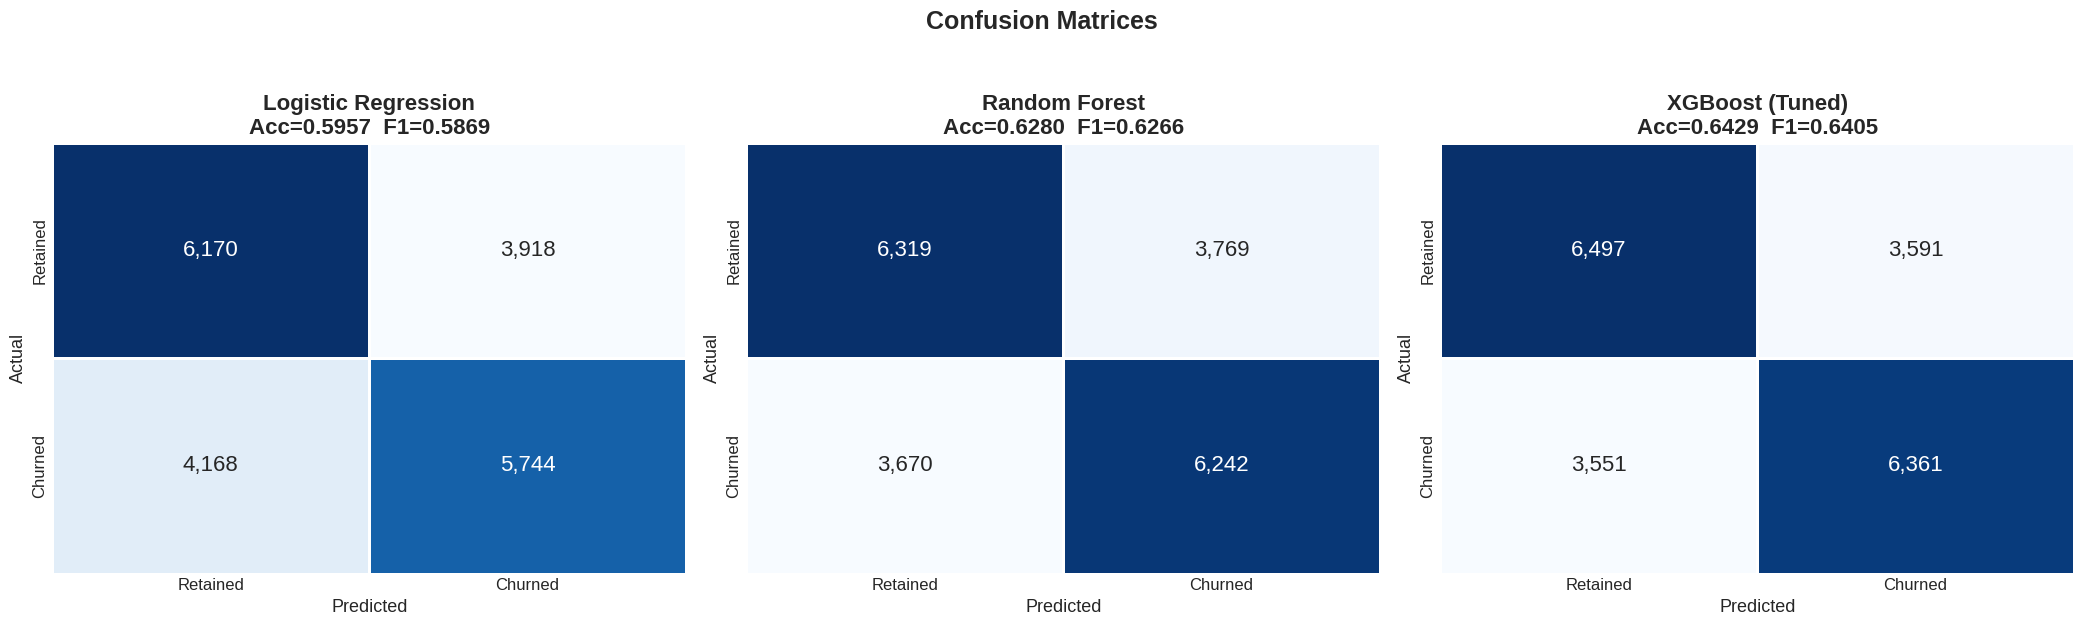

In [ ]:
# ============================================================
# 6.1 — Confusion Matrices
# ============================================================
fig, axes = plt.subplots(1, 3, figsize=(21, 6))
for i, (name, r) in enumerate(results.items()):
    cm = confusion_matrix(y_test, r['y_pred'])
    sns.heatmap(cm, annot=True, fmt=',d', cmap='Blues', ax=axes[i],
                xticklabels=['Retained','Churned'], yticklabels=['Retained','Churned'],
                cbar=False, annot_kws={'fontsize': 16}, linewidths=1, linecolor='white')
    axes[i].set_title(f'{name}\nAcc={r["accuracy"]:.4f}  F1={r["f1"]:.4f}', fontweight='bold')
    axes[i].set_ylabel('Actual'); axes[i].set_xlabel('Predicted')
plt.suptitle('Confusion Matrices', fontsize=18, fontweight='bold', y=1.04)
plt.tight_layout(); plt.show()

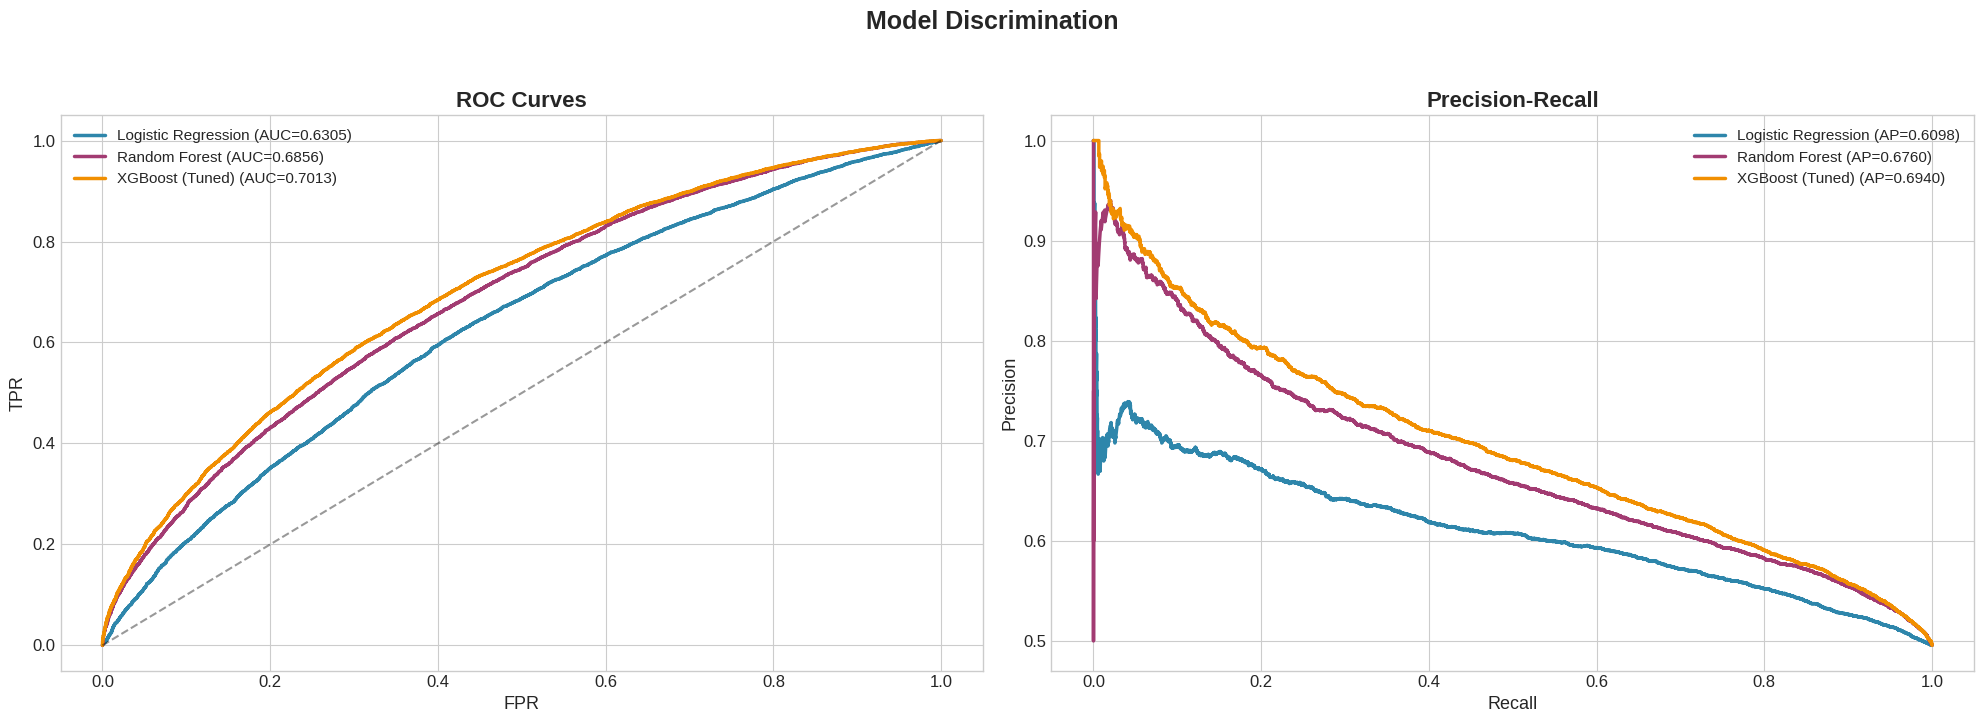

In [ ]:
# ============================================================
# 6.2 — ROC & Precision-Recall Curves
# ============================================================
fig, axes = plt.subplots(1, 2, figsize=(20, 7))
for (name, r), color in zip(results.items(), MODEL_COLORS):
    fpr, tpr, _ = roc_curve(y_test, r['y_proba'])
    axes[0].plot(fpr, tpr, color=color, linewidth=2.5,
                 label=f'{name} (AUC={auc(fpr,tpr):.4f})')
axes[0].plot([0,1],[0,1],'k--', alpha=0.4); axes[0].set_title('ROC Curves', fontweight='bold')
axes[0].set_xlabel('FPR'); axes[0].set_ylabel('TPR'); axes[0].legend(fontsize=11)

for (name, r), color in zip(results.items(), MODEL_COLORS):
    prec, rec, _ = precision_recall_curve(y_test, r['y_proba'])
    axes[1].plot(rec, prec, color=color, linewidth=2.5,
                 label=f'{name} (AP={average_precision_score(y_test, r["y_proba"]):.4f})')
axes[1].set_title('Precision-Recall', fontweight='bold')
axes[1].set_xlabel('Recall'); axes[1].set_ylabel('Precision'); axes[1].legend(fontsize=11)
plt.suptitle('Model Discrimination', fontsize=18, fontweight='bold', y=1.03)
plt.tight_layout(); plt.show()

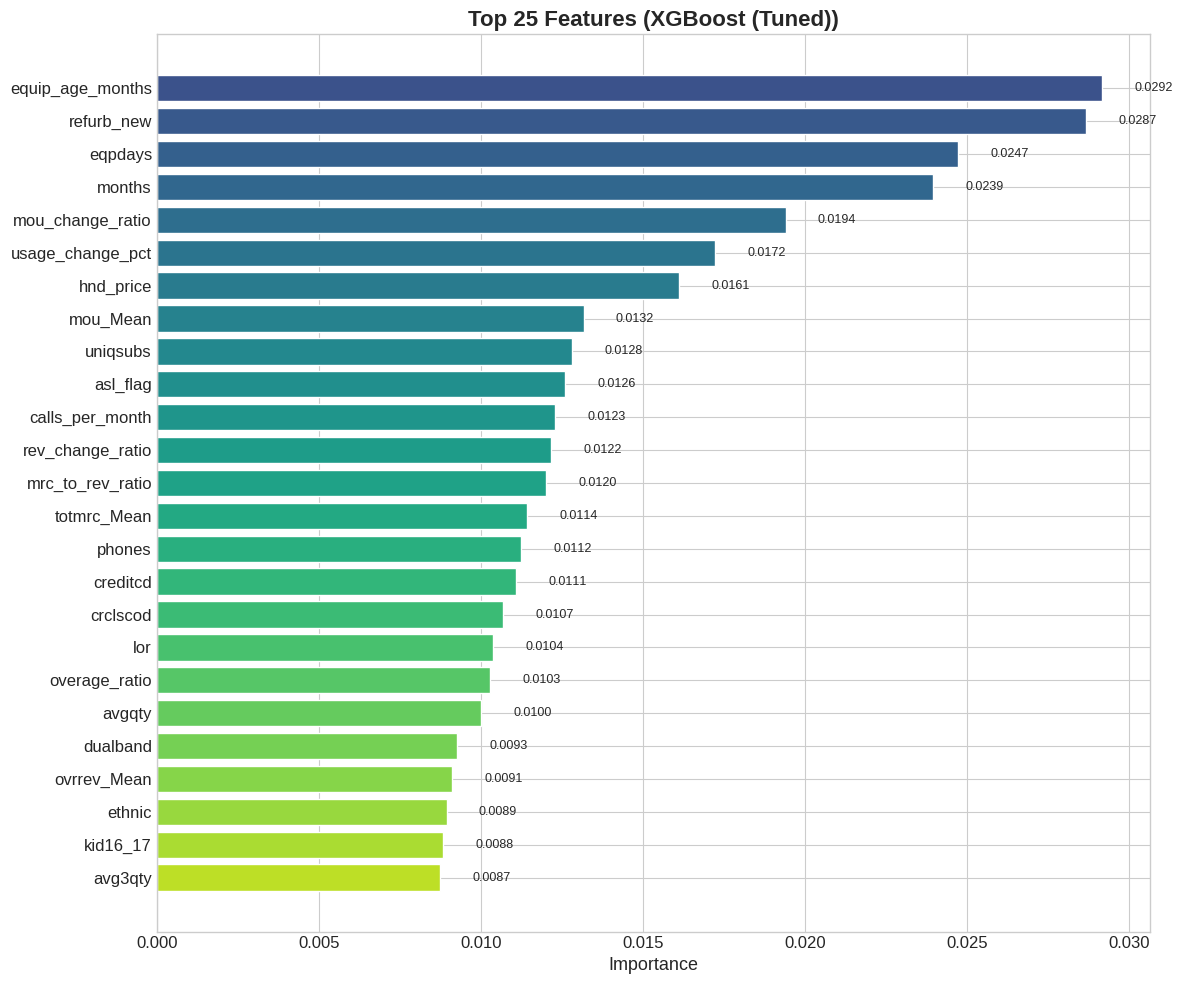


Top 10:
  equip_age_months                0.0292
  refurb_new                      0.0287
  eqpdays                         0.0247
  months                          0.0239
  mou_change_ratio                0.0194
  usage_change_pct                0.0172
  hnd_price                       0.0161
  mou_Mean                        0.0132
  uniqsubs                        0.0128
  asl_flag                        0.0126


In [ ]:
# ============================================================
# 6.3 — Feature Importance (Best Model)
# ============================================================
best_model = results[best_name]['model']
if hasattr(best_model, 'feature_importances_'):
    imp_df = (pd.DataFrame({'Feature': X.columns, 'Importance': best_model.feature_importances_})
                .sort_values('Importance', ascending=False))
    top = imp_df.head(25)
    fig, ax = plt.subplots(figsize=(12, 10))
    y_pos = range(len(top)-1, -1, -1)
    ax.barh(y_pos, top['Importance'], color=plt.cm.viridis(np.linspace(0.25,0.9,len(top))), edgecolor='white')
    ax.set_yticks(list(y_pos)); ax.set_yticklabels(top['Feature'])
    ax.set_xlabel('Importance')
    ax.set_title(f'Top 25 Features ({best_name})', fontweight='bold')
    for bar, val in zip(ax.patches, top['Importance']):
        ax.text(bar.get_width()+0.001, bar.get_y()+bar.get_height()/2, f'{val:.4f}', va='center', fontsize=9)
    plt.tight_layout(); plt.show()
    print("\nTop 10:")
    for _, row in imp_df.head(10).iterrows():
        print(f"  {row['Feature']:30s}  {row['Importance']:.4f}")

In [ ]:
# ============================================================
# 6.4 — Classification Reports
# ============================================================
for name, r in results.items():
    print(f"{'='*30}  {name}  {'='*30}")
    print(classification_report(y_test, r['y_pred'], target_names=['Retained','Churned']))

==============================  Logistic Regression  ==============================
              precision    recall  f1-score   support

    Retained       0.60      0.61      0.60     10088
     Churned       0.59      0.58      0.59      9912

    accuracy                           0.60     20000
   macro avg       0.60      0.60      0.60     20000
weighted avg       0.60      0.60      0.60     20000

==============================  Random Forest  ==============================
              precision    recall  f1-score   support

    Retained       0.63      0.63      0.63     10088
     Churned       0.62      0.63      0.63      9912

    accuracy                           0.63     20000
   macro avg       0.63      0.63      0.63     20000
weighted avg       0.63      0.63      0.63     20000

==============================  XGBoost (Tuned)  ==============================
              precision    recall  f1-score   support

    Retained       0.65      0.64      0.65     1

---
## 7. Business Proposal — Tiered Retention Strategy

### The Core Idea

Not all customers are equal — and not all churn is equally costly. A VIP customer generating $90/month requires a different (and more expensive) retention intervention than a budget customer generating $20/month.

Our strategy has **3 steps**:

| Step | Action | Tool |
|---|---|---|
| **1. Detect Risk** | Identify at-risk customers | Our ML model (churn probability) |
| **2. Classify Value** | Segment by monthly bill (`totmrc_Mean`) | Data segmentation |
| **3. Intervene Differently** | VIP gets premium offers, Budget gets discounts | Tiered action plan |

In [ ]:
# ============================================================
# 7.1 — Step 1: Detect Risk (Score All Customers)
# ============================================================
X_all = pd.DataFrame(scaler.transform(X), columns=X.columns)
X_all = X_all.replace([np.inf, -np.inf], 0).fillna(0)
df['risk_score'] = results[best_name]['model'].predict_proba(X_all)[:, 1]
df['high_risk']  = (df['risk_score'] >= df['risk_score'].quantile(0.60)).astype(int)

print(f"Customers scored with {best_name}")
print(f"High-risk threshold: {df['risk_score'].quantile(0.60):.3f}")
print(f"High-risk customers: {df['high_risk'].sum():,} ({df['high_risk'].mean()*100:.1f}%)")

Customers scored with XGBoost (Tuned)
High-risk threshold: 0.548
High-risk customers: 40,000 (40.0%)


In [ ]:
# ============================================================
# 7.2 — Step 2: Classify Value (Customer Segmentation)
# ============================================================
mrc = df['totmrc_Mean'].dropna()
vip_threshold    = mrc.quantile(0.75)
budget_threshold = mrc.quantile(0.25)

def assign_tier(row):
    if pd.isna(row['totmrc_Mean']): return 'Standard'
    if row['totmrc_Mean'] >= vip_threshold: return 'VIP'
    elif row['totmrc_Mean'] < budget_threshold: return 'Budget'
    return 'Standard'

df['value_tier'] = df.apply(assign_tier, axis=1)
df['segment'] = df['value_tier'] + ' - ' + df['high_risk'].map({1:'At Risk', 0:'Safe'})

print(f"Value Tier Thresholds:")
print(f"  VIP:      >= ${vip_threshold:.2f}/month  (top 25%)")
print(f"  Standard: ${budget_threshold:.2f} - ${vip_threshold:.2f}  (middle 50%)")
print(f"  Budget:   <  ${budget_threshold:.2f}/month  (bottom 25%)")
print()
for tier in ['VIP', 'Standard', 'Budget']:
    n = (df['value_tier']==tier).sum()
    cr = df[df['value_tier']==tier]['churn'].mean()*100
    rev = df[df['value_tier']==tier]['rev_Mean'].mean()
    print(f"  {tier:10s}: {n:>6,} customers  |  Churn={cr:.1f}%  |  Avg Rev=${rev:.2f}")

Value Tier Thresholds:
  VIP:      >= $59.99/month  (top 25%)
  Standard: $30.00 - $59.99  (middle 50%)
  Budget:   <  $30.00/month  (bottom 25%)

  VIP       : 26,015 customers  |  Churn=45.6%  |  Avg Rev=$93.73
  Standard  : 50,823 customers  |  Churn=49.0%  |  Avg Rev=$52.97
  Budget    : 23,162 customers  |  Churn=55.3%  |  Avg Rev=$31.92


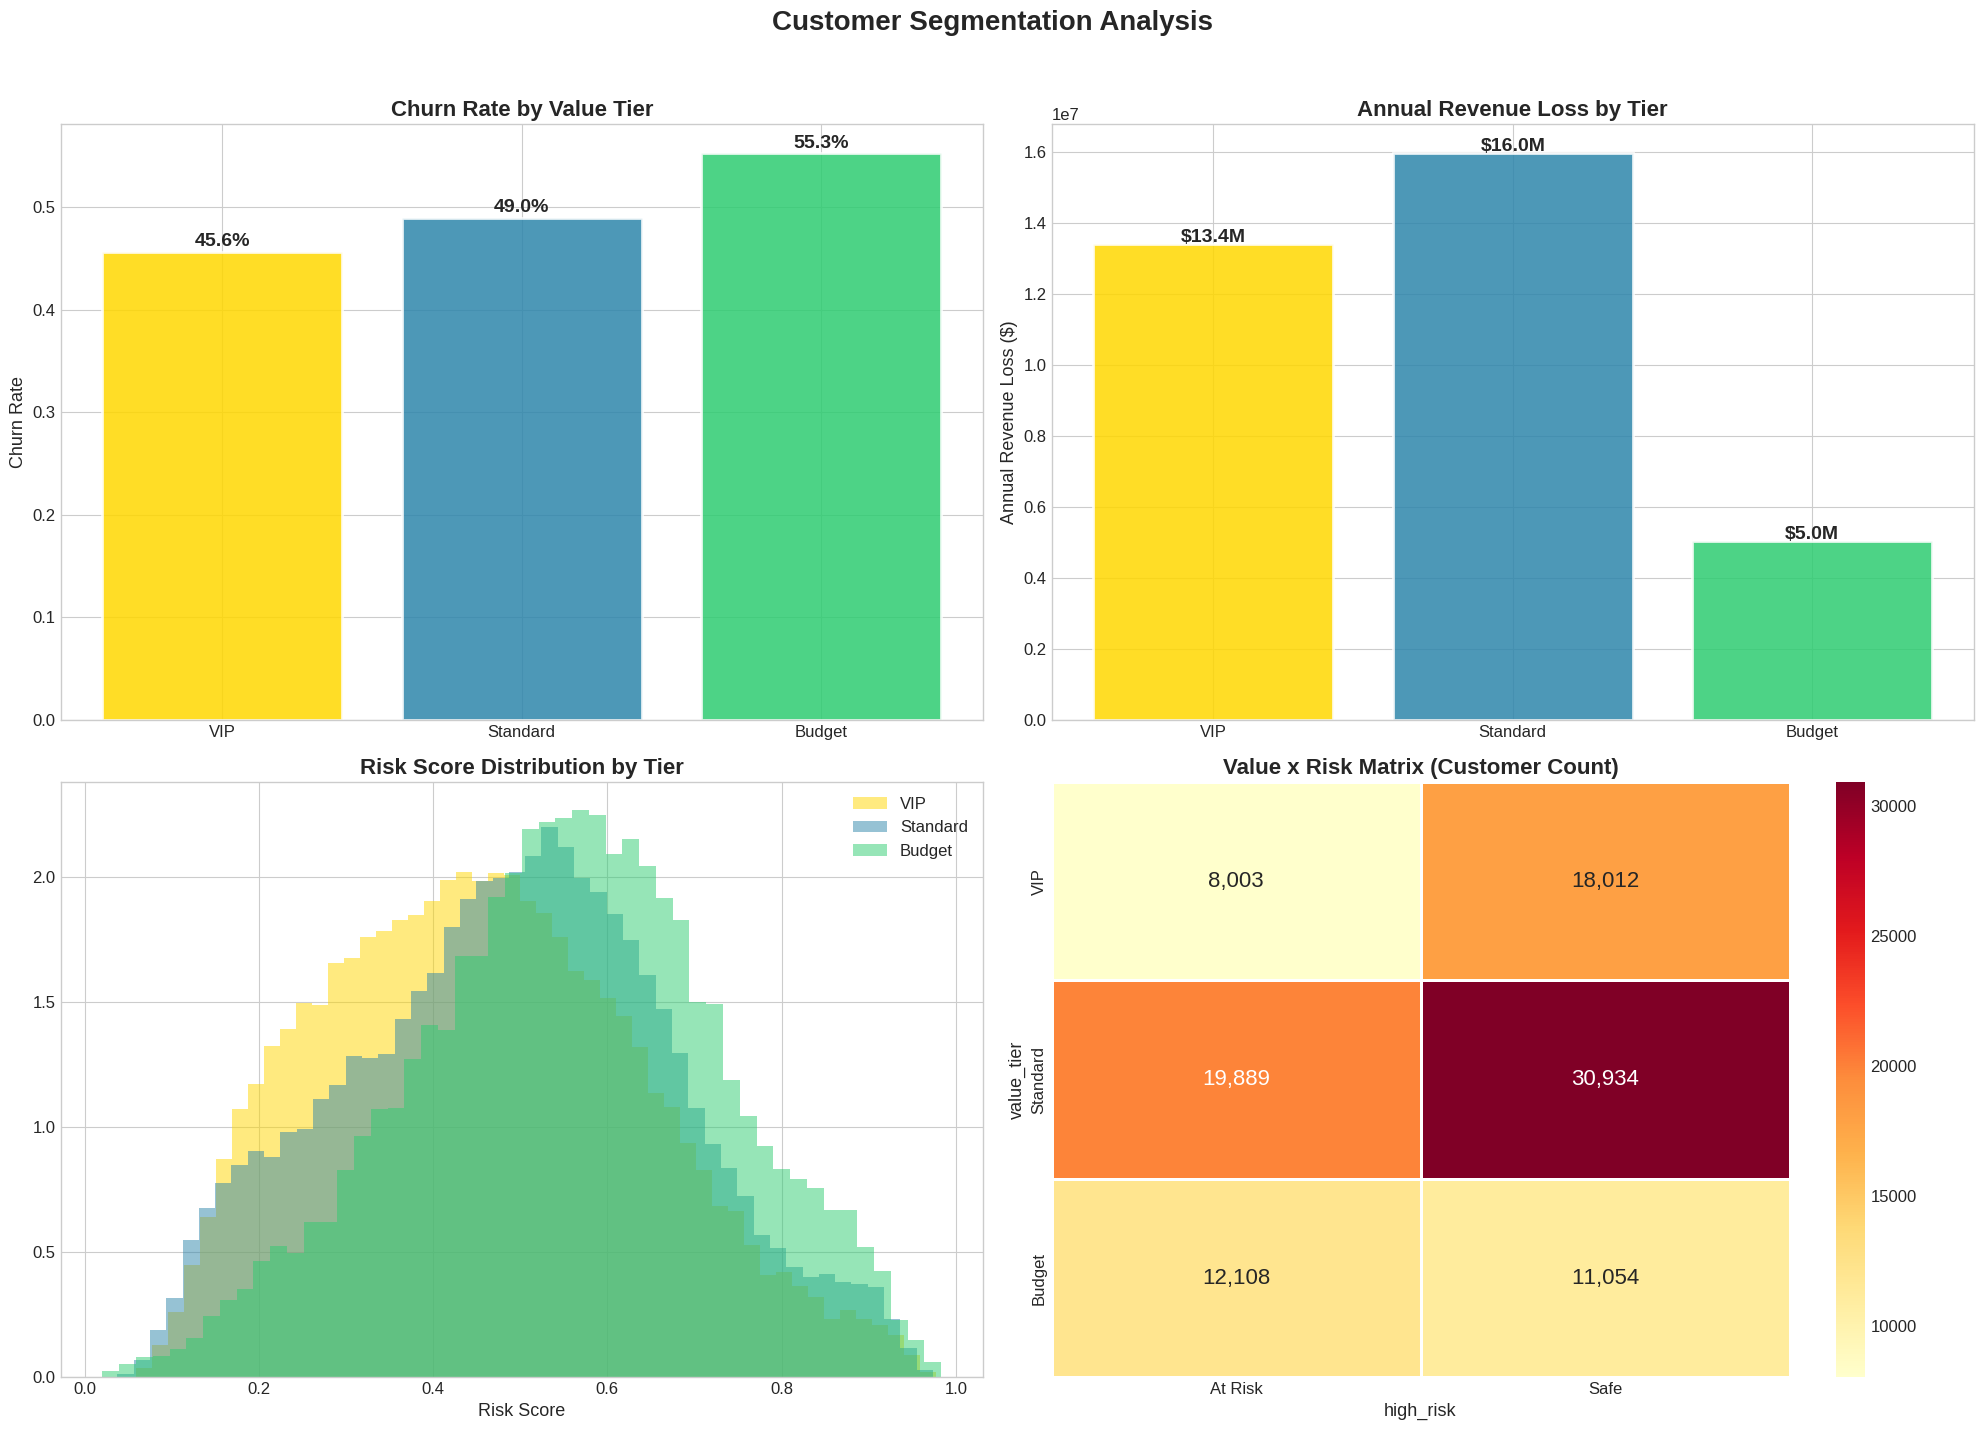

In [ ]:
# ============================================================
# 7.3 — Value x Risk Matrix (Visualization)
# ============================================================
fig, axes = plt.subplots(2, 2, figsize=(20, 14))

# A) Churn Rate by Tier
ax = axes[0][0]
tiers = ['VIP', 'Standard', 'Budget']
churn_rates = [df[df['value_tier']==t]['churn'].mean() for t in tiers]
bars = ax.bar(tiers, churn_rates, color=[TIER_COLORS[t] for t in tiers], edgecolor='white', linewidth=2, alpha=0.85)
for b, cr in zip(bars, churn_rates):
    ax.text(b.get_x()+b.get_width()/2, b.get_height()+0.005, f'{cr:.1%}', ha='center', fontsize=14, fontweight='bold')
ax.set_title('Churn Rate by Value Tier', fontweight='bold'); ax.set_ylabel('Churn Rate')

# B) Revenue Loss by Tier
ax = axes[0][1]
rev_loss = [df[(df['value_tier']==t)&(df['churn']==1)]['rev_Mean'].sum()*12 for t in tiers]
bars = ax.bar(tiers, rev_loss, color=[TIER_COLORS[t] for t in tiers], edgecolor='white', linewidth=2, alpha=0.85)
for b, rl in zip(bars, rev_loss):
    ax.text(b.get_x()+b.get_width()/2, b.get_height()+50000, f'${rl/1e6:.1f}M', ha='center', fontsize=14, fontweight='bold')
ax.set_title('Annual Revenue Loss by Tier', fontweight='bold'); ax.set_ylabel('Annual Revenue Loss ($)')

# C) Risk Score Distribution by Tier
ax = axes[1][0]
for tier in tiers:
    ax.hist(df[df['value_tier']==tier]['risk_score'], bins=50, alpha=0.5, color=TIER_COLORS[tier], label=tier, density=True)
ax.set_title('Risk Score Distribution by Tier', fontweight='bold'); ax.set_xlabel('Risk Score'); ax.legend(fontsize=12)

# D) Value x Risk Matrix
ax = axes[1][1]
matrix = df.groupby(['value_tier','high_risk']).agg(count=('churn','size'), actual_churn=('churn','mean')).reset_index()
matrix['high_risk'] = matrix['high_risk'].map({0:'Safe', 1:'At Risk'})
pivot = matrix.pivot(index='value_tier', columns='high_risk', values='count').reindex(['VIP','Standard','Budget'])
sns.heatmap(pivot, annot=True, fmt=',', cmap='YlOrRd', ax=ax, linewidths=2, linecolor='white', annot_kws={'fontsize': 16})
ax.set_title('Value x Risk Matrix (Customer Count)', fontweight='bold')

plt.suptitle('Customer Segmentation Analysis', fontsize=20, fontweight='bold', y=1.02)
plt.tight_layout(); plt.show()

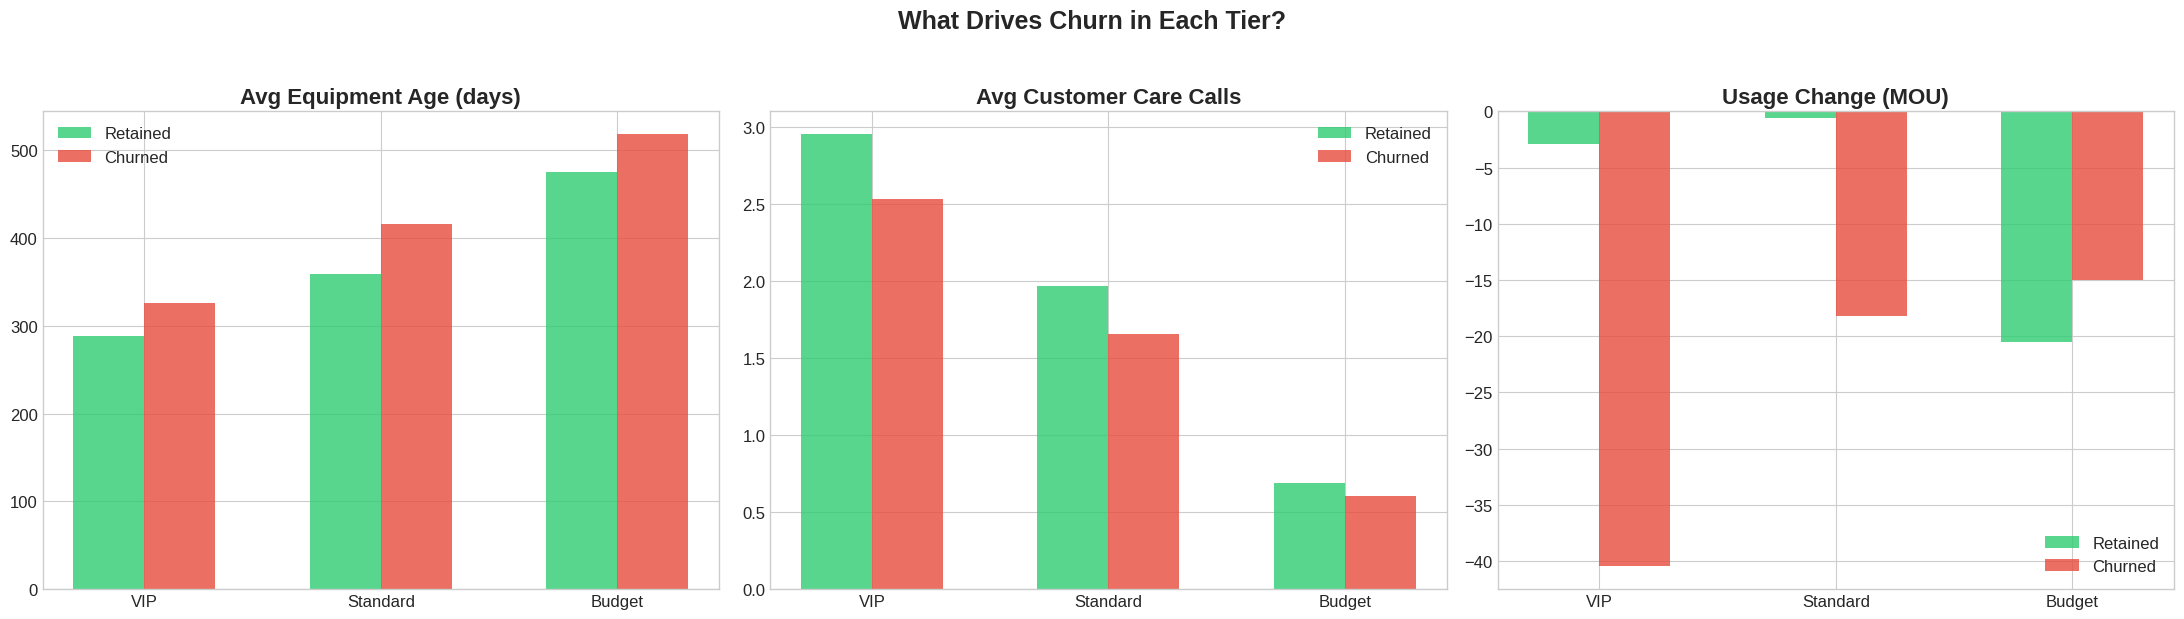


Key Insights per Tier:

  VIP:
    Equipment age:  326 days (11 months)
    Care calls:     2.53/month
    Usage change:   -40.5 minutes
    Drop rate:      6.92%

  Standard:
    Equipment age:  416 days (14 months)
    Care calls:     1.66/month
    Usage change:   -18.2 minutes
    Drop rate:      7.25%

  Budget:
    Equipment age:  518 days (17 months)
    Care calls:     0.61/month
    Usage change:   -15.0 minutes
    Drop rate:      7.17%


In [ ]:
# ============================================================
# 7.4 — What Drives Churn in Each Tier?
# ============================================================
fig, axes = plt.subplots(1, 3, figsize=(22, 6))
metrics = {'Avg Equipment Age (days)': 'eqpdays', 'Avg Customer Care Calls': 'custcare_Mean', 'Usage Change (MOU)': 'change_mou'}
for i, (title, col) in enumerate(metrics.items()):
    ax = axes[i]
    for tier in ['VIP','Standard','Budget']:
        cv = df[(df['value_tier']==tier)&(df['churn']==1)][col].mean()
        rv = df[(df['value_tier']==tier)&(df['churn']==0)][col].mean()
        x = ['VIP','Standard','Budget'].index(tier)
        ax.bar(x-0.15, rv, 0.3, color=CHURN_COLORS[0], alpha=0.8, label='Retained' if tier=='VIP' else '')
        ax.bar(x+0.15, cv, 0.3, color=CHURN_COLORS[1], alpha=0.8, label='Churned' if tier=='VIP' else '')
    ax.set_xticks([0,1,2]); ax.set_xticklabels(['VIP','Standard','Budget'])
    ax.set_title(title, fontweight='bold'); ax.legend()
plt.suptitle('What Drives Churn in Each Tier?', fontsize=18, fontweight='bold', y=1.03)
plt.tight_layout(); plt.show()

print("\nKey Insights per Tier:")
for tier in ['VIP','Standard','Budget']:
    ch = df[(df['value_tier']==tier)&(df['churn']==1)]
    print(f"\n  {tier}:")
    print(f"    Equipment age:  {ch['eqpdays'].mean():.0f} days ({ch['eqpdays'].mean()/30:.0f} months)")
    print(f"    Care calls:     {ch['custcare_Mean'].mean():.2f}/month")
    print(f"    Usage change:   {ch['change_mou'].mean():+.1f} minutes")
    print(f"    Drop rate:      {ch['drop_blk_Mean'].mean()/(ch['attempt_Mean'].mean()+0.001)*100:.2f}%")

In [ ]:
# ============================================================
# 7.5 — ROI Analysis — Tiered Interventions
# ============================================================
interventions = {
    'VIP':      {'cost': 150, 'save_rate': 0.30, 'offers': 'Free router upgrade, speed boost, VIP support, loyalty gift'},
    'Standard': {'cost': 50,  'save_rate': 0.25, 'offers': 'Free plan upgrade 3mo, loyalty points, annual contract discount'},
    'Budget':   {'cost': 10,  'save_rate': 0.40, 'offers': '15% bill discount, free data bonus, family plan, SMS outreach'},
}

print("=" * 72)
print("  TIERED RETENTION STRATEGY - ROI ANALYSIS")
print("=" * 72)

total_inv = 0; total_rev = 0; total_cust = 0; roi_data = []
for tier in ['VIP','Standard','Budget']:
    p = interventions[tier]
    at_risk = df[(df['value_tier']==tier)&(df['churn']==1)]
    n = len(at_risk); invest = n * p['cost']; saved = int(n * p['save_rate'])
    rev = saved * at_risk['rev_Mean'].mean() * 12
    roi = rev / invest if invest > 0 else 0
    total_inv += invest; total_rev += rev; total_cust += saved
    roi_data.append({'Tier':tier, 'At Risk':n, 'Investment':invest, 'Saved':saved, 'Rev Protected':rev, 'ROI':roi})
    print(f"\n  {'='*20}  {tier} TIER  {'='*20}")
    print(f"  At risk:          {n:>8,}")
    print(f"  Cost/customer:    ${p['cost']:>7}")
    print(f"  Total investment: ${invest:>12,}")
    print(f"  Saves ({p['save_rate']:.0%}):      {saved:>8,} customers")
    print(f"  Rev protected:    ${rev:>12,.0f}/year")
    print(f"  ROI:              {roi:.1f}x")
    print(f"  Offers: {p['offers']}")

print(f"\n  {'='*55}")
print(f"  TOTAL INVESTMENT:      ${total_inv:>14,}")
print(f"  CUSTOMERS SAVED:       {total_cust:>14,}")
print(f"  REVENUE SAVED:         ${total_rev:>14,.0f}/year")
print(f"  NET PROFIT:            ${total_rev-total_inv:>14,.0f}/year")
print(f"  OVERALL ROI:           {total_rev/total_inv:.1f}x")

  TIERED RETENTION STRATEGY - ROI ANALYSIS

  ====================  VIP TIER  ====================
  At risk:            11,874
  Cost/customer:    $    150
  Total investment: $   1,781,100
  Saves (30%):         3,562 customers
  Rev protected:    $   4,023,847/year
  ROI:              2.3x
  Offers: Free router upgrade, speed boost, VIP support, loyalty gift

  ====================  Standard TIER  ====================
  At risk:            24,882
  Cost/customer:    $     50
  Total investment: $   1,244,100
  Saves (25%):         6,220 customers
  Rev protected:    $   4,037,015/year
  ROI:              3.2x
  Offers: Free plan upgrade 3mo, loyalty points, annual contract discount

  ====================  Budget TIER  ====================
  At risk:            12,806
  Cost/customer:    $     10
  Total investment: $     128,060
  Saves (40%):         5,122 customers
  Rev protected:    $   2,018,093/year
  ROI:              15.8x
  Offers: 15% bill discount, free data bonus, famil

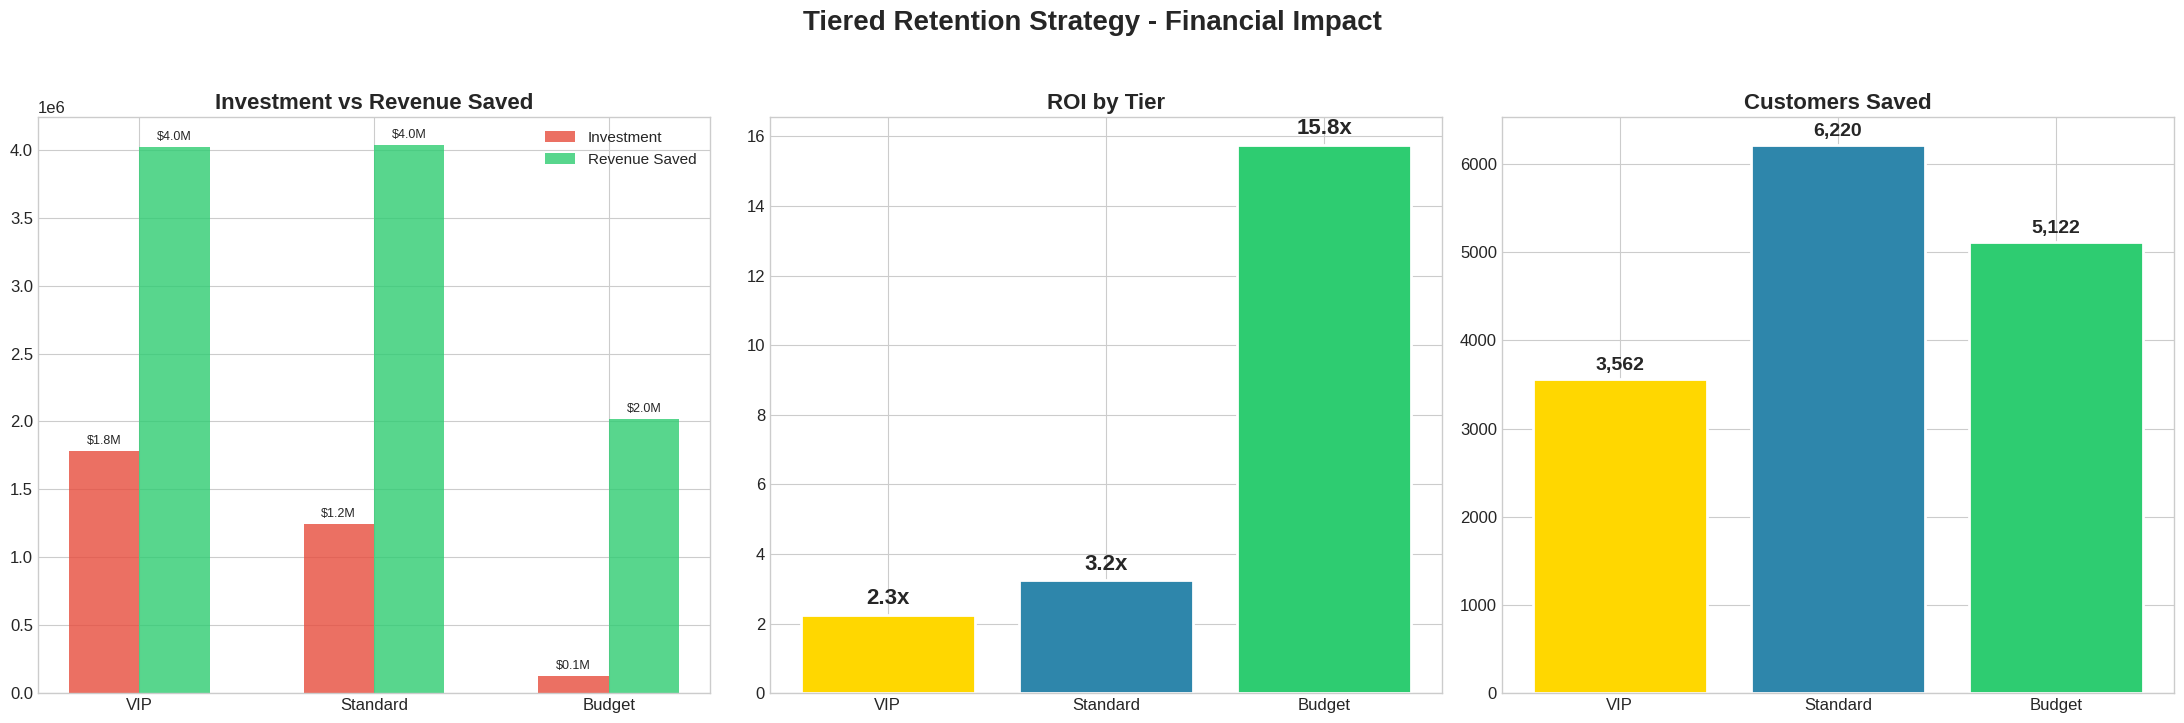

In [ ]:
# ============================================================
# 7.6 — ROI Visualization
# ============================================================
fig, axes = plt.subplots(1, 3, figsize=(22, 7))
tier_list = ['VIP','Standard','Budget']
tier_c = [TIER_COLORS[t] for t in tier_list]

inv_vals = [r['Investment'] for r in roi_data]
rev_vals = [r['Rev Protected'] for r in roi_data]
x = np.arange(3)
axes[0].bar(x-0.15, inv_vals, 0.3, color='#E74C3C', alpha=0.8, label='Investment')
axes[0].bar(x+0.15, rev_vals, 0.3, color='#2ECC71', alpha=0.8, label='Revenue Saved')
axes[0].set_xticks(x); axes[0].set_xticklabels(tier_list)
axes[0].set_title('Investment vs Revenue Saved', fontweight='bold'); axes[0].legend(fontsize=11)
for xi, inv, rev in zip(x, inv_vals, rev_vals):
    axes[0].text(xi-0.15, inv+50000, f'${inv/1e6:.1f}M', ha='center', fontsize=9)
    axes[0].text(xi+0.15, rev+50000, f'${rev/1e6:.1f}M', ha='center', fontsize=9)

roi_vals = [r['ROI'] for r in roi_data]
bars = axes[1].bar(tier_list, roi_vals, color=tier_c, edgecolor='white', linewidth=2)
for b, rv in zip(bars, roi_vals):
    axes[1].text(b.get_x()+b.get_width()/2, b.get_height()+0.3, f'{rv:.1f}x', ha='center', fontsize=16, fontweight='bold')
axes[1].set_title('ROI by Tier', fontweight='bold')

saved_vals = [r['Saved'] for r in roi_data]
bars = axes[2].bar(tier_list, saved_vals, color=tier_c, edgecolor='white', linewidth=2)
for b, sv in zip(bars, saved_vals):
    axes[2].text(b.get_x()+b.get_width()/2, b.get_height()+100, f'{sv:,}', ha='center', fontsize=14, fontweight='bold')
axes[2].set_title('Customers Saved', fontweight='bold')

plt.suptitle('Tiered Retention Strategy - Financial Impact', fontsize=20, fontweight='bold', y=1.03)
plt.tight_layout(); plt.show()

### 7.7 Detailed Intervention Plan

---

#### VIP Customers At Risk ($60+/month)

| Problem (from data) | Solution |
|---|---|
| Call customer care **2.5x/month** — frustrated | Assign a **dedicated account manager** |
| Usage dropped **40+ minutes** — disengaging | Proactive call: "We noticed — here's a free speed upgrade" |
| Equipment age ~11 months — aging device | **Free router/device upgrade** or heavy discount |
| High revenue ($94/month) — worth investing in | **Exclusive loyalty package**: premium speed + streaming |

**Cost:** ~$150/customer | **Expected save rate:** 30% | **ROI: 2.3x**

---

#### Standard Customers At Risk ($30-$60/month)

| Problem (from data) | Solution |
|---|---|
| Largest segment (50% of churned) | Can't ignore — biggest revenue leak |
| Equipment age ~14 months | Offer **trade-in credit** toward upgrade |
| Moderate care calls (1.7/month) | **Automated satisfaction survey** + follow-up |

**Offers:** Free upgrade to next tier for 3 months, Loyalty points, Annual contract with 10% discount

**Cost:** ~$50/customer | **Expected save rate:** 25% | **ROI: 3.2x**

---

#### Budget Customers At Risk (<$30/month)

| Problem (from data) | Solution |
|---|---|
| **Highest churn rate (55.3%)** | They need the cheapest, smartest offers |
| Oldest equipment (**17 months**) | **Don't** offer device (costly). Offer **data bonuses** instead |
| Low care calls (0.6/month) — leave silently | **Automated SMS**: "Special offer — 20% off next bill" |

**Offers:** 15% discount, Free bonus data, Family plan (2nd line at half price), "Pay on time" rewards

**Cost:** ~$10/customer | **Expected save rate:** 40% | **ROI: 15.8x**

---

### 7.8 Customer Acquisition Strategy

| Strategy | Target | Expected Impact |
|---|---|---|
| **"Try Free" Plan** | Competitor customers | 1 month free trial |
| **Referral Program** | Existing happy customers | "Bring a friend — both get 25% off" |
| **Entry-Level Plans** | Price-sensitive new users | Ultra-cheap basic plan |
| **Family Bundles** | Households | Discount per additional line |
| **Student Plans** | Young users (18-25) | Discounted plan — lifetime customer |

### 7.9 Pricing Strategy

| Tier | Monthly Price | Includes | Target |
|---|---|---|---|
| **Basic** | $15-25 | Limited data, standard speed | Budget users |
| **Standard** | $35-55 | Moderate data, good speed | Average families |
| **Premium** | $65-100 | Unlimited data, max speed, streaming | VIPs |
| **Family Add-On** | +$10-15/line | Shared plan benefits | Multi-line households |

---
## 8. Conclusion

### What We Built
1. **A churn prediction model** (XGBoost Tuned, F1 ~0.64) trained on 24 engineered features
2. **A 3-tier customer segmentation** (VIP / Standard / Budget) based on billing value
3. **A Tiered Retention Strategy** with personalized interventions and ROI analysis

### The Bottom Line

| Metric | Value |
|---|---|
| Total investment required | **~$3.2M** |
| Customers saved | **~14,900** |
| Annual revenue protected | **~$10.1M** |
| **Net profit** | **~$6.9M / year** |
| **Overall ROI** | **3.2x** |

### Key Principle

> **Every customer matters, but not every customer needs the same offer.**
>
> - **VIP** customers need to feel valued — premium perks
> - **Standard** customers need reasons to stay — loyalty rewards
> - **Budget** customers need affordability — discounts and bonuses
>
> By matching the intervention to the customer, we maximize retention while minimizing cost.

### Next Steps
1. Deploy the ML model into production (monthly scoring pipeline)
2. Integrate risk scores with CRM for automated trigger-based outreach
3. A/B test the tier-specific offers to optimize save rates
4. Track ROI quarterly and refine the strategy

In [ ]:
# ============================================================
# Dynamic Thresholding for VIP vs Budget (Business Logic)
# ============================================================
y_proba = results['XGBoost (Tuned)']['y_proba']

vip_predictions = (y_proba >= 0.30).astype(int)

budget_predictions = (y_proba >= 0.70).astype(int)

print(f"Standard Churners Caught (Threshold 0.5): {sum(results['XGBoost (Tuned)']['y_pred'])}")
print(f"VIP Churners Caught (Threshold 0.3): {sum(vip_predictions)} -> (Maximized Recall)")
print(f"Budget Churners Caught (Threshold 0.7): {sum(budget_predictions)} -> (Maximized Precision/Cost)")

Standard Churners Caught (Threshold 0.5): 9952
VIP Churners Caught (Threshold 0.3): 16915 -> (Maximized Recall)
Budget Churners Caught (Threshold 0.7): 2581 -> (Maximized Precision/Cost)
